# Introduction to Geospatial Data Analysis 2024 - 2025
## Final Mini Project - Due: April 16
### Isil Oral & Tatyana Yakushina

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

In [1]:
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.geometry import box
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
#import h3

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results

### Urban green spaces data 
Data is from 'Open Data Austria', obtained through *Riepl et. al (2025)*

In [4]:
file_name = 'data/OEFFGRUENFLOGD.json'
gdf_green = gpd.read_file(file_name)
gdf_green.head(3)

,id,OBJECTID,TEXT13ID,F_TYP,T_TEXT,T_LANG,O,P,O_UEREG,O_REGION,...,Q_GRI,Q_HUN,Q_BAB,Q_WC,Q_SPO,Q_TRB,UMFANG,FLAECHE,SE_ANNO_CAD_DATA,geometry
0,OEFFGRUENFLOGD.2289,2289,Währinger Pa*,L,Währinger Park,Währinger Park,1,100000,0,0,...,0,1,0,1,1245,1,1460.941451,57020.131903,None,"MULTIPOLYGON (((16.35083 48.23369, 16.34929 48..."
1,OEFFGRUENFLOGD.2290,2290,Türkenschanz*,L,Türkenschanzplatz,Türkenschanzplatz,1,1,0,0,...,0,0,0,0,0,0,310.900196,2002.715993,None,"POLYGON ((16.32886 48.23482, 16.32824 48.23492..."
2,OEFFGRUENFLOGD.2291,2291,Kongreßpark,L,Kongreßpark/Kainzga,Kainzgasse,1,100000,0,0,...,0,1,0,2,12,1,249.284876,3243.484789,None,"POLYGON ((16.30871 48.22281, 16.30933 48.22285..."


In [5]:
# to learn whether there is metadata, if yes what columns mean

import fiona
with fiona.open(file_name) as src:
    #print(src.schema)  # Gives field names and types
    print(src.meta)    # Sometimes includes more metadata

{'driver': 'GeoJSON', 'schema': {'properties': {'id': 'str', 'OBJECTID': 'int32', 'TEXT13ID': 'str', 'F_TYP': 'str', 'T_TEXT': 'str', 'T_LANG': 'str', 'O': 'int32', 'P': 'int', 'O_UEREG': 'int32', 'O_REGION': 'int32', 'O_LOKAL': 'int32', 'P_WLD': 'int32', 'P_WAS': 'int32', 'P_WIE': 'int32', 'P_WGT': 'int32', 'P_LW': 'int32', 'P_PK': 'int32', 'P_GPK': 'int32', 'P_GST': 'int32', 'P_SGR': 'int32', 'P_AGR': 'int32', 'P_RGR': 'int32', 'P_URB': 'int32', 'Q_MOB': 'int32', 'Q_SPI': 'int32', 'Q_GRI': 'int32', 'Q_HUN': 'int32', 'Q_BAB': 'int32', 'Q_WC': 'int32', 'Q_SPO': 'int32', 'Q_TRB': 'int32', 'UMFANG': 'float', 'FLAECHE': 'float', 'SE_ANNO_CAD_DATA': 'str'}, 'geometry': 'Unknown'}, 'crs': CRS.from_epsg(4326), 'crs_wkt': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAS

### Some social and economic data for each census district of Vienna
Data is from 'Open Data Austria', obtained through *Riepl et. al (2025)*

In [6]:
gdf_census = gpd.read_file('data/data_ssi.geojson')
gdf_census

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((16.37903 48.21187, 16.37902 48.21188..."
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"POLYGON ((16.37906 48.20748, 16.37882 48.20755..."
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,"POLYGON ((16.36893 48.20072, 16.36905 48.20072..."
3,0104,1.845975,3.156000,1.697713,1.313290,2.407460,5,"POLYGON ((16.36326 48.2039, 16.36383 48.20424,..."
4,0105,1.681303,2.424953,1.192502,1.252134,1.971322,5,"POLYGON ((16.36765 48.21307, 16.36843 48.21273..."
...,...,...,...,...,...,...,...,...
241,2315,1.267620,2.076986,1.032159,0.955199,1.604961,5,"POLYGON ((16.26417 48.15314, 16.26433 48.1532,..."
242,2316,-0.038446,0.315260,0.839466,0.834993,0.412143,4,"POLYGON ((16.23894 48.15341, 16.23821 48.15312..."
243,2317,-0.410833,0.503589,0.921774,1.088109,0.406096,4,"POLYGON ((16.37712 48.14752, 16.37708 48.14753..."
244,2318,-1.138054,-0.177753,-0.123182,0.210761,-0.470587,2,"POLYGON ((16.34062 48.1487, 16.34051 48.14871,..."


In [7]:
with fiona.open('data/data_ssi.geojson') as src:
    #sprint(src.schema)  # Gives field names and types
    print(src.meta)    # Sometimes includes more metadata

{'driver': 'GeoJSON', 'schema': {'properties': {'ZBEZ': 'str', 'university_share': 'float', 'avg_income': 'float', 'unemprate': 'float', 'benefit_share': 'float', 'SSI': 'float', 'quintile': 'int32'}, 'geometry': 'Polygon'}, 'crs': CRS.from_epsg(4326), 'crs_wkt': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'}


### Data for blue spaces and administrative boundaries
Data is from OpenStreetMap

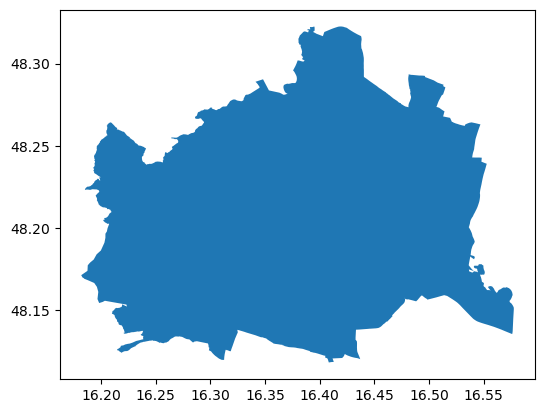

In [8]:
admin_city = ox.geocode_to_gdf('Vienna')
admin_city.plot()
plt.show()

**Blue spaces** are "Outdoor environments—natural or manmade—that prominently feature water, and are accessible and offer opportunities for recreation, relaxation, or aesthetic appreciation." (According to the World Health Organization (WHO) and related research (e.g., BlueHealth project))

This includes:
- Oceans and seas
- Rivers, lakes, ponds
- Canals, streams
- Urban fountains, reservoirs (if accessible)
- Wetlands (if part of nature/recreation areas)

They exclude:
- Wastewater facilities
- Industrial drainage systems
- Hidden/underground pipes
- Non-recreational, restricted areas (e.g. dams, treatment plants)


In [9]:
# Define the polygon for the administrative 
admin_poly = admin_city.geometry.values[0]


# Download POIs for blue spaces within the administrative boundary
tags_blue = {
    'natural': ['water', 'wetland'],
    'waterway': ['stream', 'river', 'canal'],
    'water': ['pond', 'lake', 'reservoir', 'basin', 'fishpond']
}
blue = ox.features_from_polygon(admin_poly, tags=tags_blue)

print("Water sources:", len(blue))
print("Type of data:", type(blue))
blue.head(3)

Water sources: 2207
Type of data: <class 'geopandas.geodataframe.GeoDataFrame'>


geometry  \
element  id                                                              
node     6813960988                          POINT (16.41034 48.13083)   
relation 75          POLYGON ((16.42474 48.22954, 16.42471 48.22955...   
         18443       POLYGON ((16.5844 48.1324, 16.58205 48.13265, ...   

                    river:waterway_distance waterway source  \
element  id                                                   
node     6813960988                     NaN      NaN    NaN   
relation 75                             NaN      NaN    NaN   
         18443                          NaN      NaN    NaN   

                                  name alt_name name:cs name:de name:es  \
element  id                                                               
node     6813960988                NaN      NaN     NaN     NaN     NaN   
relation 75          Untere Alte Donau      NaN     NaN     NaN     NaN   
         18443                     NaN      NaN     NaN     NaN     NaN   

                    name:sk  ... toilets:wheelchair memorial fence_type sport  \
element  id                  ...                                                
node     6813960988     NaN  ...                NaN      NaN        NaN   NaN   
relation 75             NaN  ...                NaN      NaN        NaN   NaN   
         18443          NaN  ...                NaN      NaN        NaN   NaN   

                    abandoned  lit odbl attraction name:sh species:wikidata  
element  id                                                                  
node     6813960988       NaN  NaN  NaN        NaN     NaN              NaN  
relation 75               NaN  NaN  NaN        NaN     NaN              NaN  
         18443            NaN  NaN  NaN        NaN     NaN              NaN  

[3 rows x 132 columns]

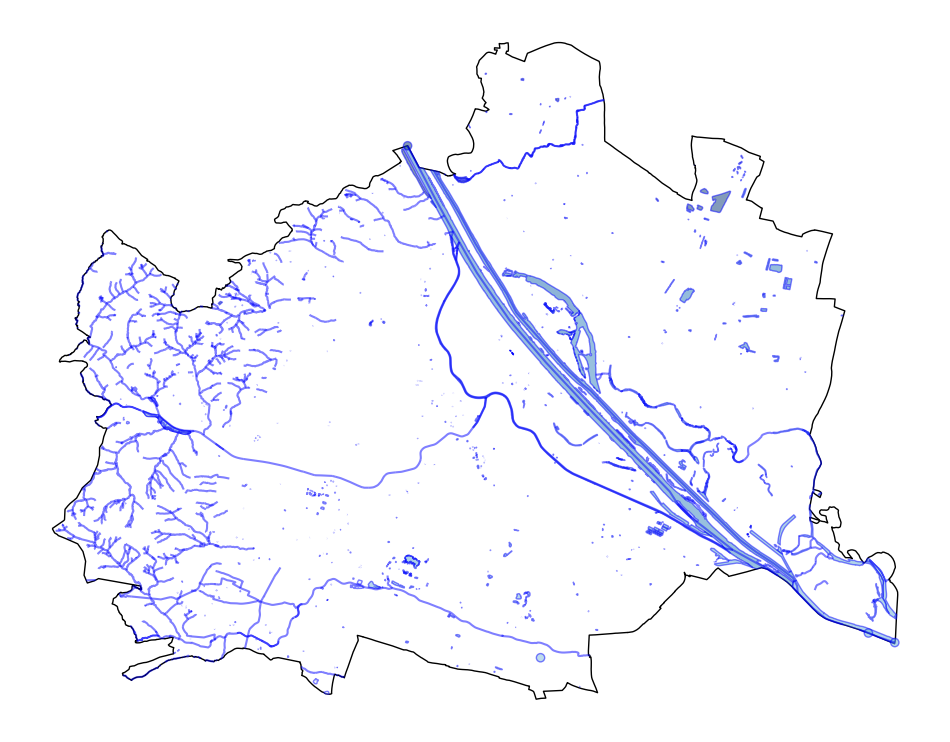

In [10]:
blue_clipped = gpd.clip(blue, admin_city)

# Create a plot to visualize the admin boundary and blue spaces
f, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the parks
blue_clipped.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')

# Customize the plot
ax.axis('off')
plt.show()

### Further green space data
from OSM

In [11]:
'''
greens = ox.features_from_polygon(admin_poly, tags={'leisure': 'nature_reserve', 'leisure': 'garden', 'leisure': 'park', 'amenity': 'graveyard', 'landuse': 'cemetery', 'landuse': 'recreation_ground', 'landuse': 'forest'})

print("Green spaces:", len(greens))
print("Type of data:", type(greens))
greens.head()
'''

'\ngreens = ox.features_from_polygon(admin_poly, tags={\'leisure\': \'nature_reserve\', \'leisure\': \'garden\', \'leisure\': \'park\', \'amenity\': \'graveyard\', \'landuse\': \'cemetery\', \'landuse\': \'recreation_ground\', \'landuse\': \'forest\'})\n\nprint("Green spaces:", len(greens))\nprint("Type of data:", type(greens))\ngreens.head()\n'

In [12]:
'''
# Create a plot to visualize the admin boundary and green spaces
f, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the parks
greens.plot(ax=ax, cmap='Greens', alpha=0.5, edgecolor='darkgreen')

# Customize the plot
ax.axis('off')
plt.show()
'''

"\n# Create a plot to visualize the admin boundary and green spaces\nf, ax = plt.subplots(1, 1, figsize=(12, 12))\n\n# Plot the administrative boundary\nadmin_city.plot(ax=ax, color='none', edgecolor='k')\n\n# Plot the parks\ngreens.plot(ax=ax, cmap='Greens', alpha=0.5, edgecolor='darkgreen')\n\n# Customize the plot\nax.axis('off')\nplt.show()\n"

In [13]:
'''
# both greens and blues by using OSM:
# to show the overlap of green and blue spaces in Vienna
f, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the parks
greens.plot(ax=ax, cmap='Greens', alpha=0.5, edgecolor='darkgreen')
blue_clipped.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')

# Customize the plot
ax.axis('off')
plt.show()
'''

"\n# both greens and blues by using OSM:\n# to show the overlap of green and blue spaces in Vienna\nf, ax = plt.subplots(1, 1, figsize=(12, 12))\n\n# Plot the administrative boundary\nadmin_city.plot(ax=ax, color='none', edgecolor='k')\n\n# Plot the parks\ngreens.plot(ax=ax, cmap='Greens', alpha=0.5, edgecolor='darkgreen')\nblue_clipped.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')\n\n# Customize the plot\nax.axis('off')\nplt.show()\n"

## Visualizations

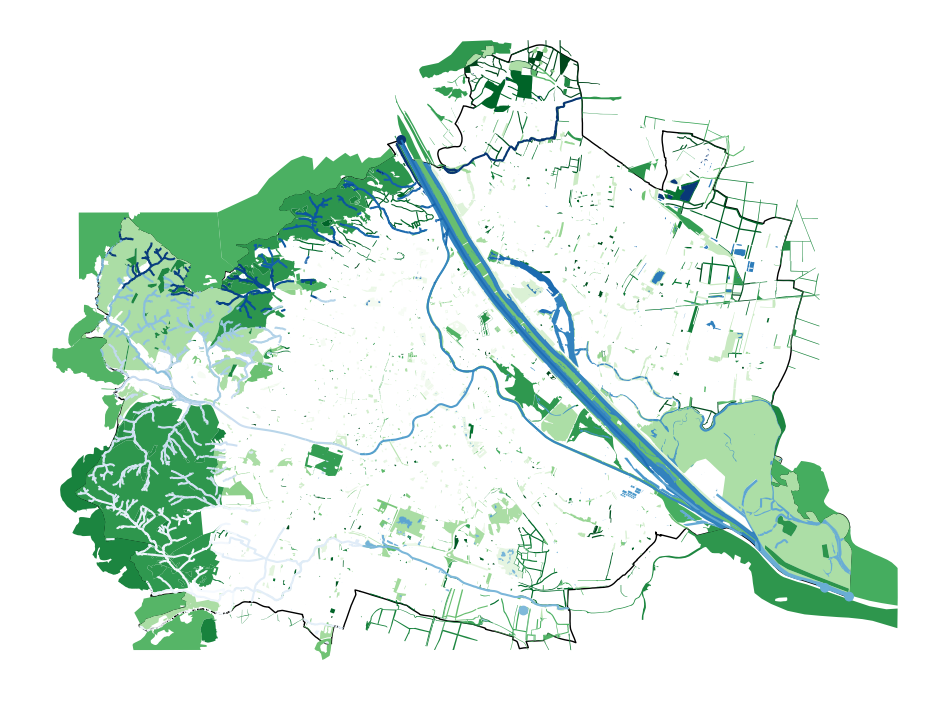

In [14]:
#greens from Open Data Austria, and blues from OSM:

f, ax = plt.subplots(1, 1, figsize=(12, 12))

admin_city.plot(ax=ax, color='none', edgecolor='k')
gdf_green.plot(ax=ax, cmap='Greens')
blue_clipped.plot(ax=ax, cmap='Blues')
ax.axis('off')

plt.savefig("output/vienna_green_blue_map.png", dpi=300, bbox_inches='tight')
plt.show()

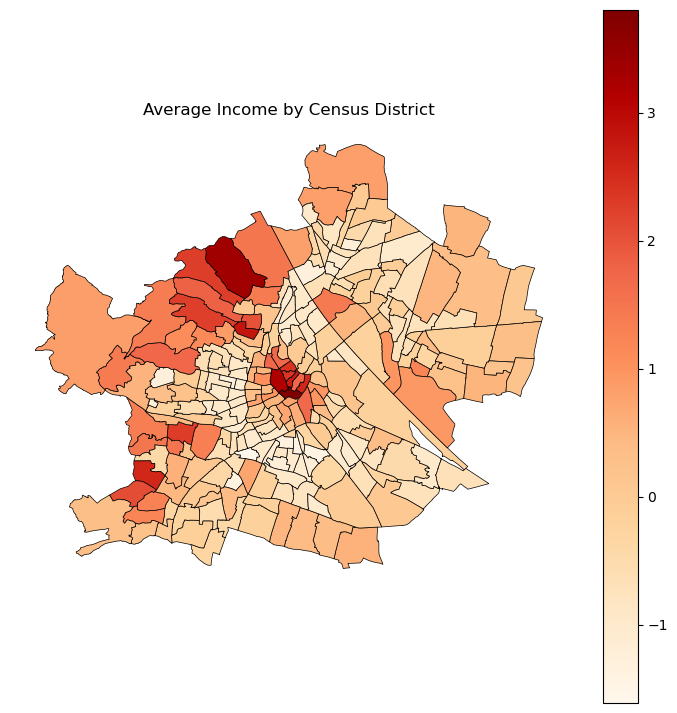

In [15]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='avg_income',     
    cmap='OrRd',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

ax.set_title("Average Income by Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/avg_income_map.png", dpi=300, bbox_inches='tight')
plt.show()

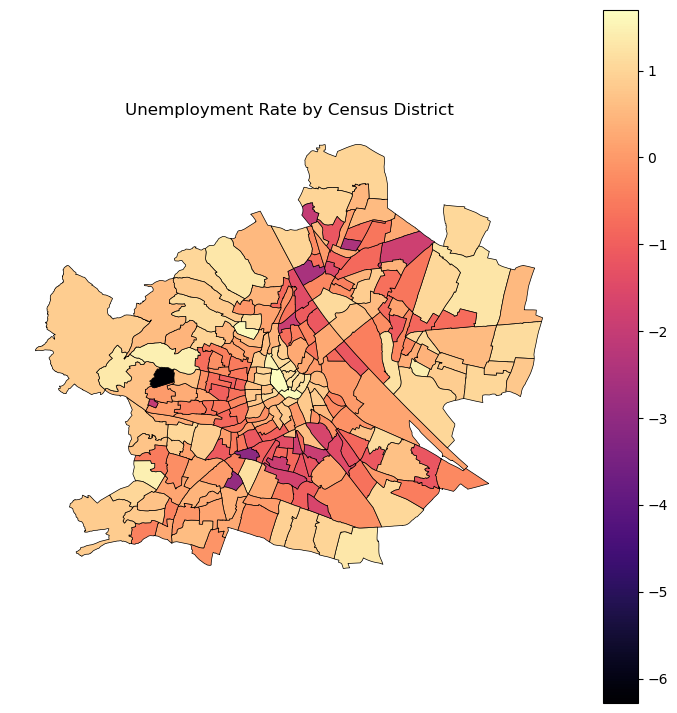

In [16]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='unemprate',      
    cmap='magma',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

ax.set_title("Unemployment Rate by Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/unemp_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

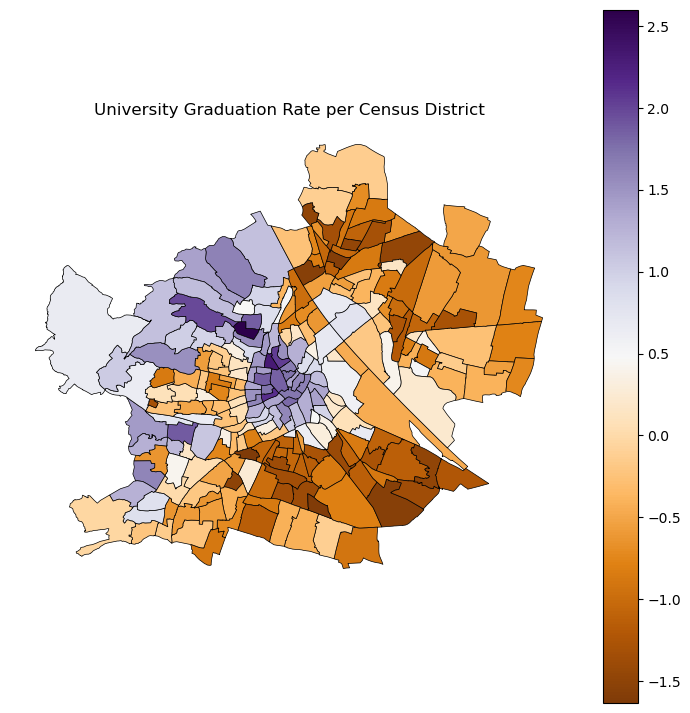

In [17]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='university_share',     
    cmap='PuOr',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,             
    ax=ax
)

ax.set_title("University Graduation Rate per Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/uni_grad_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

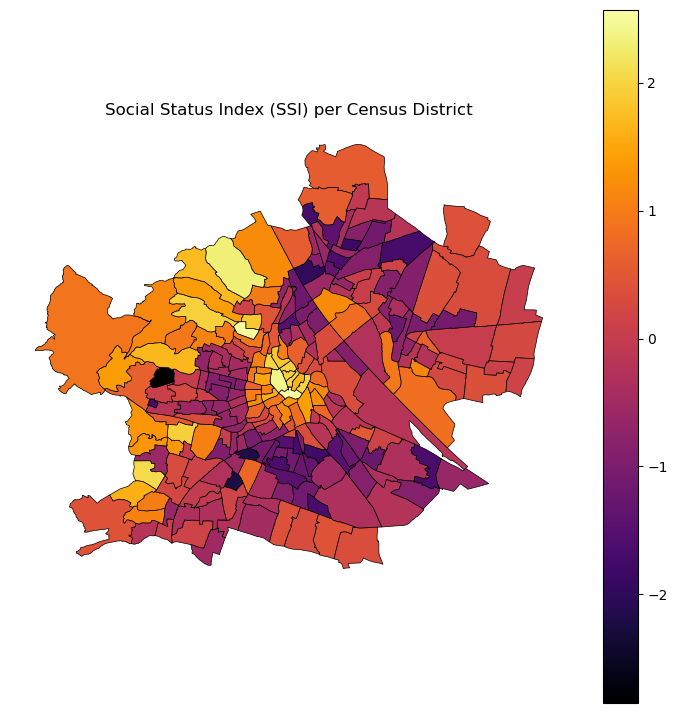

In [18]:
# Plot SSI by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='SSI',      
    cmap='inferno',              
    linewidth=0.5,           
    edgecolor='black',        
    legend=True,              
    ax=ax
)

ax.set_title("Social Status Index (SSI) per Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/ssi_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
'''
# run 4 codes above as a loop instead of running several times

# Variables and settings to loop through
plot_settings = [
    {'column': 'SSI', 'title': 'Social Status Index (SSI)', 'cmap': 'inferno', 'file': 'ssi_map.png'},
    {'column': 'avg_income', 'title': 'Average Income', 'cmap': 'OrRd', 'file': 'avg_income_map.png'},
    {'column': 'university_share', 'title': 'University Graduate Share', 'cmap': 'Greens', 'file': 'university_share_map.png'},
    {'column': 'unemprate', 'title': 'Unemployment Rate', 'cmap': 'Blues', 'file': 'unemployment_map.png'},
]

for setting in plot_settings:
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # Plot without built-in legend
    gdf_census.plot(
        column=setting['column'],
        cmap=setting['cmap'],
        linewidth=0.5,
        edgecolor='black',
        legend=False,
        ax=ax
    )

    # Custom colorbar
    norm = mpl.colors.Normalize(
        vmin=gdf_census[setting['column']].min(),
        vmax=gdf_census[setting['column']].max()
    )
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=setting['cmap'])
    sm._A = []
    
    cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.01)
    ax.set_title(f"{setting['title']} per Census District", fontsize=12)
    ax.axis('off')
    
    plt.savefig(setting['file'], dpi=300, bbox_inches='tight')
    plt.close()  # close the figure to free memory
'''

'\n# run 4 codes above as a loop instead of running several times\n\n# Variables and settings to loop through\nplot_settings = [\n    {\'column\': \'SSI\', \'title\': \'Social Status Index (SSI)\', \'cmap\': \'inferno\', \'file\': \'ssi_map.png\'},\n    {\'column\': \'avg_income\', \'title\': \'Average Income\', \'cmap\': \'OrRd\', \'file\': \'avg_income_map.png\'},\n    {\'column\': \'university_share\', \'title\': \'University Graduate Share\', \'cmap\': \'Greens\', \'file\': \'university_share_map.png\'},\n    {\'column\': \'unemprate\', \'title\': \'Unemployment Rate\', \'cmap\': \'Blues\', \'file\': \'unemployment_map.png\'},\n]\n\nfor setting in plot_settings:\n    fig, ax = plt.subplots(figsize=(9, 9))\n\n    # Plot without built-in legend\n    gdf_census.plot(\n        column=setting[\'column\'],\n        cmap=setting[\'cmap\'],\n        linewidth=0.5,\n        edgecolor=\'black\',\n        legend=False,\n        ax=ax\n    )\n\n    # Custom colorbar\n    norm = mpl.colors.Norm

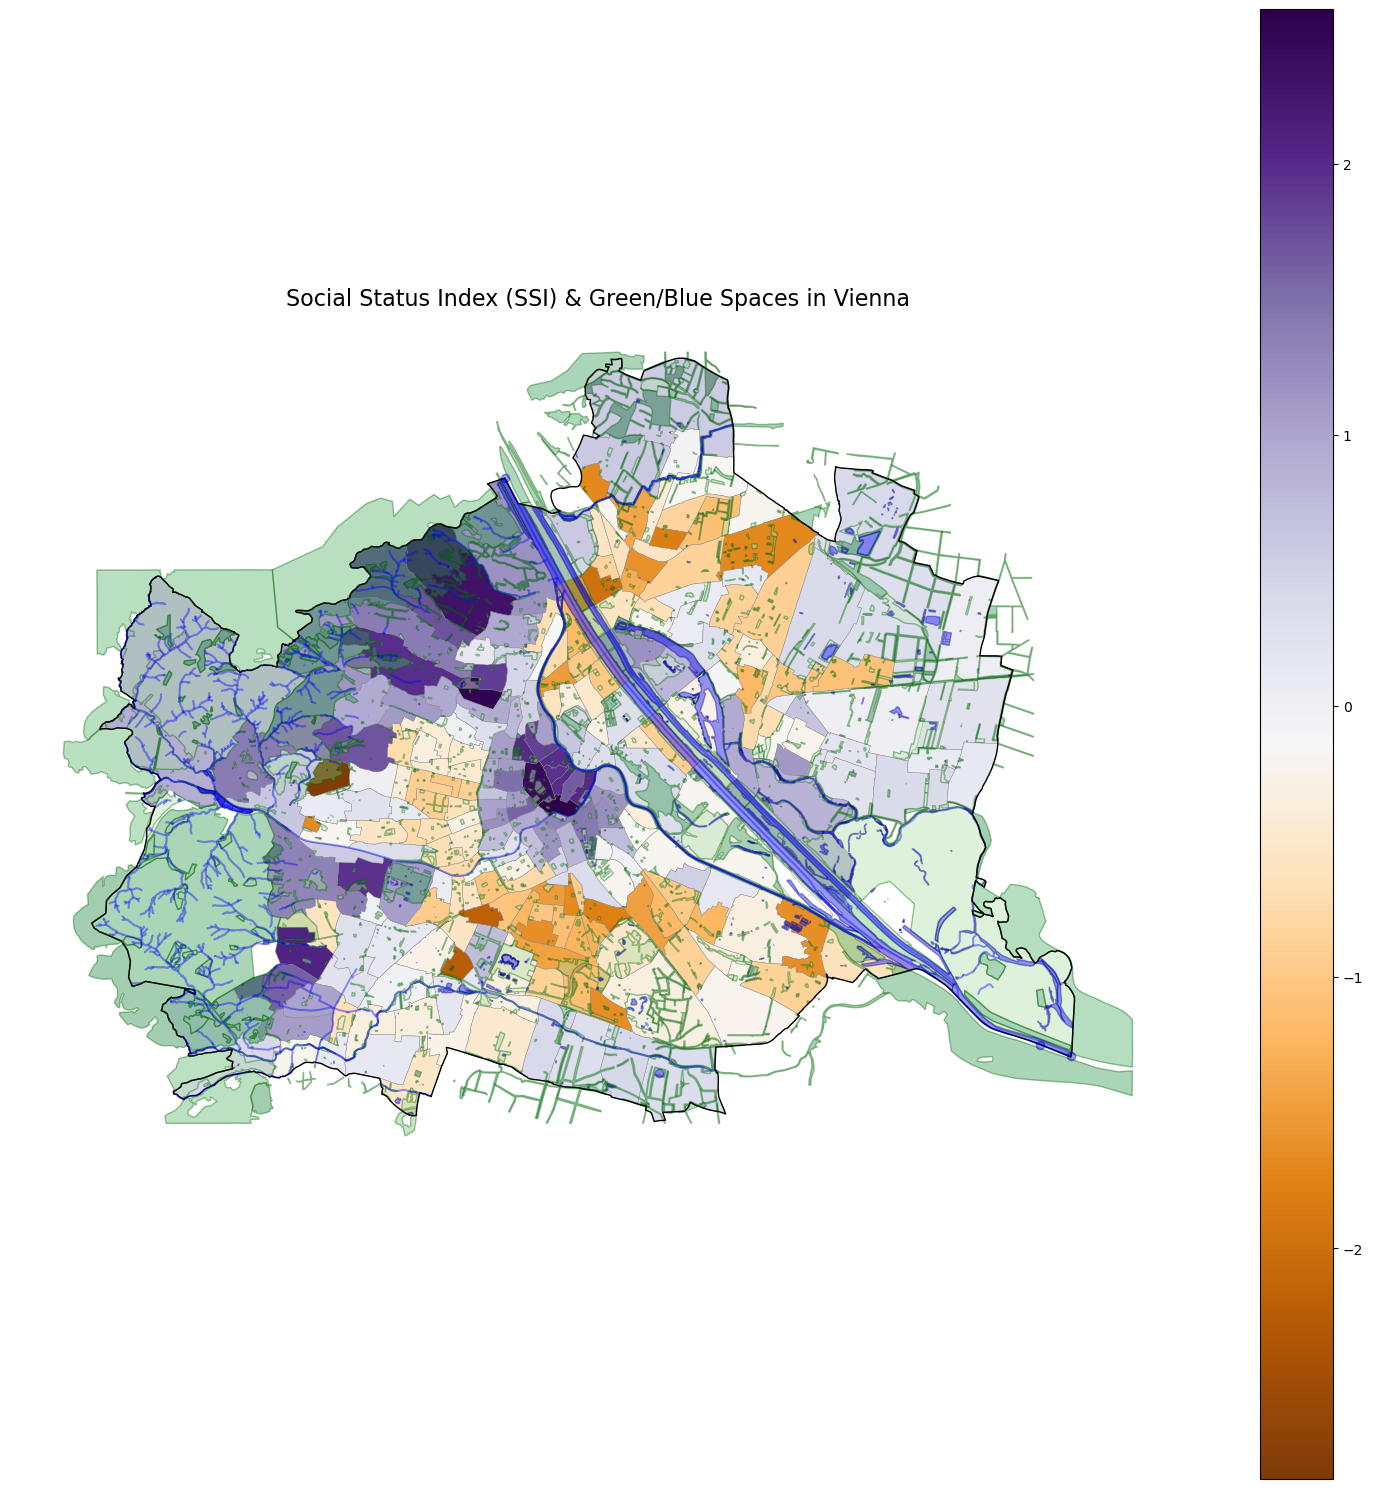

In [20]:
# Plot everything together
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot SSI as choropleth
gdf_census.plot(
    column='SSI',
    cmap='PuOr',     
    linewidth=0.3,
    edgecolor='gray',
    legend=True,
    ax=ax
)

# Overlay green and blue spaces
gdf_green.plot(ax=ax, cmap='Greens', alpha=0.4, edgecolor='darkgreen') #austrian governmental data
blue_clipped.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue') #OSM data

# Optional: plot city border
admin_city.plot(ax=ax, color='none', edgecolor='black', linewidth=1)

# Tidy up
ax.set_title("Social Status Index (SSI) & Green/Blue Spaces in Vienna", fontsize=16)
ax.axis('off')

plt.tight_layout()

plt.savefig("output/ssi_ubgs_map.png", dpi=300, bbox_inches='tight')
plt.show()


## Correlation

* How much green/blue space overlap in each census district?
* Does the existence of green/blue spaces correlated with social status index (SSI)?

In [21]:
print(gdf_census.crs)
print(gdf_green.crs)
print(blue.crs)
#print(greens.crs)
print(admin_city.crs)

# epsg 4326 is coordinates, and not good for area and periphery calculations. 
# need to change their crs. Target crs: epsg=31256

gdf_census = gdf_census.to_crs(epsg=31256)
#greens = greens.to_crs(epsg=31256)
gdf_green = gdf_green.to_crs(epsg=31256)
admin_city = admin_city.to_crs(epsg=31256)
blue = blue.to_crs(epsg=31256)


EPSG:4326
EPSG:4326
epsg:4326
epsg:4326


In [22]:
print(gdf_green.geometry.type.unique())
print(blue.geometry.type.unique())

# in order to overlay, I need same types of geometries
# seperate blue geometries into 2 different gdf: blue_lines, blue_areas

# Separate blue space geometries by type
blue_areas = blue[blue.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
blue_lines = blue[blue.geometry.type.isin(['LineString', 'MultiLineString'])].copy()

print(blue_areas.geometry.type.unique())
print(blue_lines.geometry.type.unique())

['MultiPolygon' 'Polygon']
['Point' 'Polygon' 'MultiPolygon' 'LineString']
['Polygon' 'MultiPolygon']
['LineString']


In [23]:
# green areas per district
green_clipped = gpd.clip(gdf_green, admin_city)
green_in_census = gpd.overlay(gdf_census, green_clipped, how='intersection', keep_geom_type=False)
green_in_census['green_area'] = green_in_census.geometry.area
green_area_by_district = green_in_census.groupby('ZBEZ')['green_area'].sum().reset_index()

In [24]:
# blue areas per district
blue_area_in_census = gpd.overlay(gdf_census, blue_areas, how='intersection')
blue_area_in_census['blue_area'] = blue_area_in_census.geometry.area
blue_area_by_district = blue_area_in_census.groupby('ZBEZ')['blue_area'].sum().reset_index()

# blue length per district
blue_lines_in_census = gpd.overlay(gdf_census, blue_lines, how='intersection', keep_geom_type=False)
blue_lines_in_census['blue_length'] = blue_lines_in_census.geometry.length
blue_length_by_district = blue_lines_in_census.groupby('ZBEZ')['blue_length'].sum().reset_index()

In [25]:
# Merge green and blue components into census dataframe
gdf_census = gdf_census.merge(green_area_by_district, on='ZBEZ', how='left')
gdf_census = gdf_census.merge(blue_area_by_district, on='ZBEZ', how='left')
gdf_census = gdf_census.merge(blue_length_by_district, on='ZBEZ', how='left')

# Fill missing values (e.g., no green/blue areas or rivers) with 0
gdf_census[['green_area', 'blue_area', 'blue_length']] = gdf_census[[
    'green_area', 'blue_area', 'blue_length']].fillna(0)

gdf_census

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,green_area,blue_area,blue_length
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((3485.019 341498.126, 3484.459 341498...",1.176752e+03,16.971625,0.000000
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"POLYGON ((3487.789 341009.066, 3470.019 341017...",7.766804e+04,34107.715249,1181.722444
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,"POLYGON ((2735.149 340257.116, 2743.919 340257...",2.507098e+04,135.225705,1090.379031
3,0104,1.845975,3.156000,1.697713,1.313290,2.407460,5,"POLYGON ((2313.839 340611.086, 2356.209 340648...",2.133390e+05,944.004931,0.000000
4,0105,1.681303,2.424953,1.192502,1.252134,1.971322,5,"POLYGON ((2639.529 341630.546, 2697.199 341592...",1.760884e+04,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
241,2315,1.267620,2.076986,1.032159,0.955199,1.604961,5,"POLYGON ((-5057.481 334968.716, -5045.251 3349...",5.373882e+05,947.283495,5093.774456
242,2316,-0.038446,0.315260,0.839466,0.834993,0.412143,4,"POLYGON ((-6934.151 335000.496, -6988.981 3349...",4.979837e+06,11678.685814,16166.888751
243,2317,-0.410833,0.503589,0.921774,1.088109,0.406096,4,"POLYGON ((3347.019 334342.706, 3344.129 334343...",1.714858e+05,9746.425345,1091.829646
244,2318,-1.138054,-0.177753,-0.123182,0.210761,-0.470587,2,"POLYGON ((631.009 334472.496, 622.769 334473.4...",2.119507e+05,4391.600605,0.000000


In [26]:
# Calculate district area in square kilometers (since CRS is in meters)
gdf_census['district_area_km2'] = gdf_census.geometry.area / 1e6

# Normalize each variable by district size
gdf_census['green_ratio'] = gdf_census['green_area'] / gdf_census['district_area_km2']
gdf_census['blue_area_ratio'] = gdf_census['blue_area'] / gdf_census['district_area_km2']
gdf_census['blue_length_km'] = gdf_census['blue_length'] / 1000  # optional, km of river

In [27]:
#COMMENT: DO IT BY EXCLUDING INNERE STADT. IT HAS HIGH SSI, BUT HISTROICAL BUILDINGS LESS UBGS
# Correlation matrix
corr_matrix = gdf_census[['SSI', 'green_ratio', 'blue_area_ratio', 'blue_length_km']].corr()
print(corr_matrix)

                      SSI  green_ratio  blue_area_ratio  blue_length_km
SSI              1.000000     0.204862        -0.053523        0.163702
green_ratio      0.204862     1.000000         0.308180        0.638585
blue_area_ratio -0.053523     0.308180         1.000000        0.138026
blue_length_km   0.163702     0.638585         0.138026        1.000000


In [28]:
'''
# to visualize correlations in scatter plots
import seaborn as sns

sns.pairplot(gdf_census[['SSI', 'green_ratio', 'blue_area_ratio', 'blue_length_km']])
plt.show()
'''

"\n# to visualize correlations in scatter plots\nimport seaborn as sns\n\nsns.pairplot(gdf_census[['SSI', 'green_ratio', 'blue_area_ratio', 'blue_length_km']])\nplt.show()\n"

In [29]:
import statsmodels.api as sm

# Prepare data
X = gdf_census[['university_share', 'avg_income', 'unemprate', 'benefit_share', 'green_ratio', 'blue_area_ratio', 'blue_length_km']]
X = sm.add_constant(X)  # adds intercept term
A = gdf_census[['university_share', 'avg_income', 'unemprate', 'benefit_share']]
A = sm.add_constant(A)  # adds intercept term
B = gdf_census[['green_ratio', 'blue_area_ratio', 'blue_length_km']]
B = sm.add_constant(B)  # adds intercept term
y = gdf_census['SSI']

# Fit model
model = sm.OLS(y, X).fit()
model2 =sm.OLS(y, A).fit()
model3 =sm.OLS(y, B).fit()
print(model.summary())
print(model2.summary())
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    SSI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.745e+23
Date:                Wed, 16 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:00:59   Log-Likelihood:                 5855.9
No. Observations:                 246   AIC:                        -1.170e+04
Df Residuals:                     238   BIC:                        -1.167e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             6.908e-12   9.68e-13  

In [30]:
# Prepare data
X = gdf_census['SSI']
X = sm.add_constant(X)  # adds intercept term
y = gdf_census[['green_ratio']]

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            green_ratio   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     10.69
Date:                Wed, 16 Apr 2025   Prob (F-statistic):            0.00123
Time:                        14:00:59   Log-Likelihood:                -3260.6
No. Observations:                 246   AIC:                             6525.
Df Residuals:                     244   BIC:                             6532.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.088e+05   8839.373     12.307      0.0

## Introduction of housing data into the analysis

* Data is from Statistiks Austria. 
* Does the existence of green/blue spaces affect the housing prices in that district?
* If they affect, can we check how it changes with proximity of housing to green/blue space?

In [31]:
# !pip install odfpy pandas
# Load ODS file and list all sheet names
housing_path = "data/SpecialEvaluation.ods" 
housing_data = pd.read_excel(housing_path, engine="odf", sheet_name=None)

# Show available sheets
print(housing_data.keys())

dict_keys(['Apartment_Prices', 'House_Prices', 'Building_Plots', 'Federal_Provinces', 'Apartment_Prices_municipalities', 'House_Prices_municipalities', 'Fed__states_and_constr__Periods'])


In [32]:
housing_data = pd.read_excel(
    housing_path,
    engine="odf",
    sheet_name="Apartment_Prices",  
    header=1                        # use row 2 as column names
)
housing_data.columns

Index(['D. CD.', 'Districts', 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023],
      dtype='object')

In [33]:
# Keep only Vienna rows
housing_vienna = housing_data[
    housing_data['Districts'].str.contains('Wien', na=False) &
    ~housing_data['Districts'].str.contains('Wiener Neustadt', na=False)
]
housing_vienna.columns = housing_vienna.columns.astype(str)

housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()
housing_vienna

/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_20204/1985756449.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()


,D. CD.,Districts,2015,2016,2017,2018,2019,2020,2021,2022,2023,district_clean
93,901,"Wien 1.,Innere Stadt",6569,7861,9368,10955,11186,10947,13078,14389,12733,Innere Stadt
94,902,"Wien 2.,Leopoldstadt",3650,4125,4327,4482,4590,5215,5331,6181,5494,Leopoldstadt
95,903,"Wien 3.,Landstraße",3934,4039,4483,4787,4375,5483,5715,5850,5635,Landstraße
96,904,"Wien 4.,Wieden",4189,4237,4932,5195,5650,5586,6471,7776,6646,Wieden
97,905,"Wien 5.,Margareten",3272,3500,3548,3662,3796,4634,5648,5440,4562,Margareten
98,906,"Wien 6.,Mariahilf",4147,4349,4089,4124,4836,5208,5696,5822,5325,Mariahilf
99,907,"Wien 7.,Neubau",4774,4553,4755,5405,5833,6043,6332,6336,5929,Neubau
100,908,"Wien 8.,Josefstadt",4020,4744,5292,4975,4798,5996,7842,7697,6148,Josefstadt
101,909,"Wien 9.,Alsergrund",4106,4132,4942,5215,5250,5321,5734,6234,6017,Alsergrund
102,910,"Wien 10.,Favoriten",2436,3331,3191,3942,3913,3571,3567,4211,3796,Favoriten


In [34]:
districts = gpd.read_file('data/vienna_districts.geojson') # districts data from GIS course hw2
districts

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,STATAUSTR0,FLAECHE,UMFANG,AKT_TIMEST,SE_SDO_ROW,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,91301.0,3.771397e+07,29668.16,2023-07-18,13126.0,"POLYGON ((16.21423 48.20652, 16.21425 48.20651..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,91501.0,3.916953e+06,9711.71,2023-07-18,13127.0,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ..."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,90701.0,1.608248e+06,5312.54,2023-07-18,13128.0,"POLYGON ((16.33873 48.20854, 16.33901 48.20849..."
3,Landstraße,3.0,III,"3., Landstraße",III. Landstraße,LANDSTRASSE,III.,03,1030.0,903.0,90301.0,7.403038e+06,13961.80,2023-07-18,13129.0,"POLYGON ((16.39662 48.20739, 16.39678 48.20656..."
4,Josefstadt,8.0,VIII,"8., Josefstadt",VIII. Josefstadt,JOSEFSTADT,VIII.,08,1080.0,908.0,90801.0,1.089946e+06,4170.30,2023-07-18,13130.0,"POLYGON ((16.34915 48.21516, 16.35099 48.21497..."
5,Innere Stadt,1.0,I,"1., Innere Stadt",I. Innere Stadt,INNERE STADT,I.,01,1010.0,901.0,90101.0,2.868774e+06,6972.75,2023-07-18,13131.0,"POLYGON ((16.37264 48.21662, 16.37314 48.21621..."
6,Ottakring,16.0,XVI,"16., Ottakring",XVI. Ottakring,OTTAKRING,XVI.,16,1160.0,916.0,91601.0,8.673047e+06,18371.12,2023-07-18,13132.0,"POLYGON ((16.27621 48.22704, 16.27646 48.22678..."
7,Alsergrund,9.0,IX,"9., Alsergrund",IX. Alsergrund,ALSERGRUND,IX.,09,1090.0,909.0,90901.0,2.967385e+06,7919.54,2023-07-18,13133.0,"POLYGON ((16.36165 48.23192, 16.36166 48.2319,..."
8,Leopoldstadt,2.0,II,"2., Leopoldstadt",II. Leopoldstadt,LEOPOLDSTADT,II.,02,1020.0,902.0,90201.0,1.924200e+07,27093.08,2023-07-18,13134.0,"POLYGON ((16.40345 48.23192, 16.40503 48.23067..."
9,Währing,18.0,XVIII,"18., Währing",XVIII. Währing,WÄHRING,XVIII.,18,1180.0,918.0,91801.0,6.347205e+06,18058.47,2023-07-18,13135.0,"POLYGON ((16.29502 48.24961, 16.29508 48.2496,..."


In [35]:
# Merging housing prices data into districts GeoDataFrame
housing_districts = districts.merge(
    housing_vienna[['district_clean', '2015', '2016', '2017', '2018', '2019', '2020',  '2021', '2022', '2023']],
    left_on='NAMEK',
    right_on='district_clean',
    how='left'
)

In [36]:
housing_districts.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,district_clean,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,Hietzing,4232,4132,4043,4423,4462,4821,5593,6159,5327
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,Rudolfsheim-Fünfhaus,2429,3369,3315,3827,3860,4111,4729,4460,4215
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,Neubau,4774,4553,4755,5405,5833,6043,6332,6336,5929


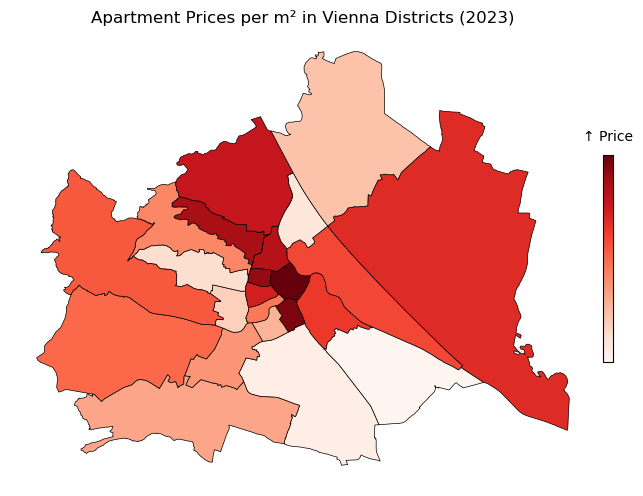

In [37]:
fig, ax = plt.subplots(figsize=(9, 9))

# Plot without legend
housing_districts_plot = housing_districts.plot(
    column='2023',
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False 
)

# Create a scalar mappable for the colorbar
norm = mpl.colors.Normalize(
    vmin=housing_districts['2023'].min(),
    vmax=housing_districts['2023'].max()
)
sm = mpl.cm.ScalarMappable(cmap='Reds', norm=norm)
sm._A = []  # required for matplotlib <3.1

# Adding the colorbar manually
cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.3,              
    pad=0.01,                
    orientation='vertical',
    location='right'         
)

# Remove ticks and add title to the colorbar
cbar.ax.set_yticks([])
cbar.ax.set_title('↑ Price', fontsize=10, pad=10)

# Final plot tweaks
ax.set_title("Apartment Prices per m² in Vienna Districts (2023)", fontsize=12)
ax.axis('off')
plt.show()

In [38]:
green_clipped = green_clipped.to_crs(districts.crs)
blue_clipped = blue_clipped.to_crs(districts.crs)

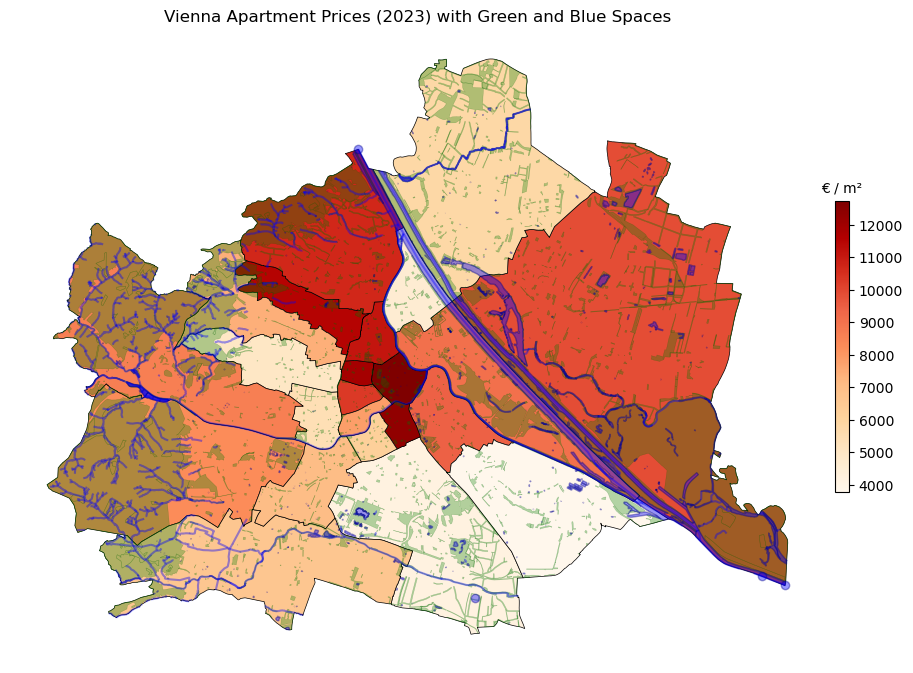

In [39]:
# Setup plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot housing prices as base choropleth
housing_districts.plot(
    column='2023',
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False  
)

# Overlay green and blue spaces
green_clipped.plot(ax=ax, color='green', alpha=0.3, edgecolor='darkgreen', linewidth=0.3)
blue_clipped.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue')

# Add colorbar manually
norm = mpl.colors.Normalize(vmin=housing_districts['2023'].min(), vmax=housing_districts['2023'].max())
sm = mpl.cm.ScalarMappable(cmap='OrRd', norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, pad=0.01)
cbar.ax.set_title('€ / m²', fontsize=10)

# Title & layout
ax.set_title("Vienna Apartment Prices (2023) with Green and Blue Spaces", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()


## Correlation of housing prices with UBGS

* Is there a correlation between the amount of green/blue spaces in districts and their average housing price per m2?

In [46]:
print(gdf_census.crs) # better crs to properly calculate length and area
housing_districts = housing_districts.to_crs(gdf_census.crs)
print(housing_districts.crs)

EPSG:31256
EPSG:31256


In [54]:
gdf_census.head(3)

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,green_area,blue_area,blue_length,district_area_km2,green_ratio,blue_area_ratio,blue_length_km
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((3485.019 341498.126, 3484.459 341498...",1176.751740,16.971625,0.000000,0.377557,3116.750799,44.951134,0.000000
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"POLYGON ((3487.789 341009.066, 3470.019 341017...",77668.038665,34107.715249,1181.722444,0.379377,204725.351202,89904.600437,1.181722
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,"POLYGON ((2735.149 340257.116, 2743.919 340257...",25070.979682,135.225705,1090.379031,0.465497,53858.536579,290.497566,1.090379


In [55]:
housing_districts

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,district_clean,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,Hietzing,4232,4132,4043,4423,4462,4821,5593,6159,5327
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,Rudolfsheim-Fünfhaus,2429,3369,3315,3827,3860,4111,4729,4460,4215
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,Neubau,4774,4553,4755,5405,5833,6043,6332,6336,5929
3,Landstraße,3.0,III,"3., Landstraße",III. Landstraße,LANDSTRASSE,III.,03,1030.0,903.0,...,Landstraße,3934,4039,4483,4787,4375,5483,5715,5850,5635
4,Josefstadt,8.0,VIII,"8., Josefstadt",VIII. Josefstadt,JOSEFSTADT,VIII.,08,1080.0,908.0,...,Josefstadt,4020,4744,5292,4975,4798,5996,7842,7697,6148
5,Innere Stadt,1.0,I,"1., Innere Stadt",I. Innere Stadt,INNERE STADT,I.,01,1010.0,901.0,...,Innere Stadt,6569,7861,9368,10955,11186,10947,13078,14389,12733
6,Ottakring,16.0,XVI,"16., Ottakring",XVI. Ottakring,OTTAKRING,XVI.,16,1160.0,916.0,...,Ottakring,2900,3176,3286,3590,4269,4221,4859,4843,4125
7,Alsergrund,9.0,IX,"9., Alsergrund",IX. Alsergrund,ALSERGRUND,IX.,09,1090.0,909.0,...,Alsergrund,4106,4132,4942,5215,5250,5321,5734,6234,6017
8,Leopoldstadt,2.0,II,"2., Leopoldstadt",II. Leopoldstadt,LEOPOLDSTADT,II.,02,1020.0,902.0,...,Leopoldstadt,3650,4125,4327,4482,4590,5215,5331,6181,5494
9,Währing,18.0,XVIII,"18., Währing",XVIII. Währing,WÄHRING,XVIII.,18,1180.0,918.0,...,Währing,4000,3855,4584,4777,4565,5047,5959,5937,6027


In [52]:
census_with_district = gpd.sjoin(
    gdf_census,
    housing_districts[['geometry', 'district_clean']], 
    how='left',
    predicate='within')

census_with_district

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,green_area,blue_area,blue_length,district_area_km2,green_ratio,blue_area_ratio,blue_length_km,index_right,district_clean
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((3485.019 341498.126, 3484.459 341498...",1.176752e+03,16.971625,0.000000,0.377557,3116.750799,44.951134,0.000000,NaN,NaN
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"POLYGON ((3487.789 341009.066, 3470.019 341017...",7.766804e+04,34107.715249,1181.722444,0.379377,204725.351202,89904.600437,1.181722,NaN,NaN
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,"POLYGON ((2735.149 340257.116, 2743.919 340257...",2.507098e+04,135.225705,1090.379031,0.465497,53858.536579,290.497566,1.090379,NaN,NaN
3,0104,1.845975,3.156000,1.697713,1.313290,2.407460,5,"POLYGON ((2313.839 340611.086, 2356.209 340648...",2.133390e+05,944.004931,0.000000,0.835823,255244.268387,1129.431566,0.000000,NaN,NaN
4,0105,1.681303,2.424953,1.192502,1.252134,1.971322,5,"POLYGON ((2639.529 341630.546, 2697.199 341592...",1.760884e+04,0.000000,0.000000,0.333293,52832.893399,0.000000,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,2315,1.267620,2.076986,1.032159,0.955199,1.604961,5,"POLYGON ((-5057.481 334968.716, -5045.251 3349...",5.373882e+05,947.283495,5093.774456,1.737267,309329.607598,545.272167,5.093774,NaN,NaN
242,2316,-0.038446,0.315260,0.839466,0.834993,0.412143,4,"POLYGON ((-6934.151 335000.496, -6988.981 3349...",4.979837e+06,11678.685814,16166.888751,6.144790,810416.144362,1900.583396,16.166889,NaN,NaN
243,2317,-0.410833,0.503589,0.921774,1.088109,0.406096,4,"POLYGON ((3347.019 334342.706, 3344.129 334343...",1.714858e+05,9746.425345,1091.829646,2.151884,79691.022595,4529.251974,1.091830,NaN,NaN
244,2318,-1.138054,-0.177753,-0.123182,0.210761,-0.470587,2,"POLYGON ((631.009 334472.496, 622.769 334473.4...",2.119507e+05,4391.600605,0.000000,2.788373,76012.324891,1574.968876,0.000000,NaN,NaN


# WHO theory

In [39]:
residential = ox.features_from_place('Vienna, Austria', tags={'building': 'residential'})
print("Number of residential buildings:", len(residential))
residential.head()

# all potential buildings
# residential_tags = {'building': ['residential', 'apartments', 'house', 'detached', 'terrace']}
# buildings = ox.features_from_place('Vienna, Austria', tags=residential_tags)
# buildings.head()

Number of residential buildings: 7756


geometry addr:city addr:country  \
element id                                                             
node    3050128807   POINT (16.45262 48.2404)      Wien           AT   
        3191378969  POINT (16.28469 48.18459)      Wien           AT   
        3191378970  POINT (16.28475 48.18473)      Wien           AT   
        4118557395  POINT (16.40081 48.21817)      Wien           AT   
        7857811759  POINT (16.25488 48.14418)       NaN          NaN   

                   addr:postcode         addr:street     building  \
element id                                                          
node    3050128807          1220       Pogrelzstraße  residential   
        3191378969          1130  Münichreiterstraße  residential   
        3191378970          1130  Münichreiterstraße  residential   
        4118557395          1020  Ausstellungsstraße  residential   
        7857811759           NaN                 NaN  residential   

                   addr:housenumber building:levels roof:levels roof:shape  \
element id                                                                   
node    3050128807              NaN             NaN         NaN        NaN   
        3191378969               39             NaN         NaN        NaN   
        3191378970               41             NaN         NaN        NaN   
        4118557395               23             NaN         NaN        NaN   
        7857811759              NaN             NaN         NaN        NaN   

                    ... level type attraction description:en location tourism  \
element id          ...                                                         
node    3050128807  ...   NaN  NaN        NaN            NaN      NaN     NaN   
        3191378969  ...   NaN  NaN        NaN            NaN      NaN     NaN   
        3191378970  ...   NaN  NaN        NaN            NaN      NaN     NaN   
        4118557395  ...   NaN  NaN        NaN            NaN      NaN     NaN   
        7857811759  ...   NaN  NaN        NaN            NaN      NaN     NaN   

                   wikipedia:en building:architecture old_name building:part  
element id                                                                    
node    3050128807          NaN                   NaN      NaN           NaN  
        3191378969          NaN                   NaN      NaN           NaN  
        3191378970          NaN                   NaN      NaN           NaN  
        4118557395          NaN                   NaN      NaN           NaN  
        7857811759          NaN                   NaN      NaN           NaN  

[5 rows x 103 columns]

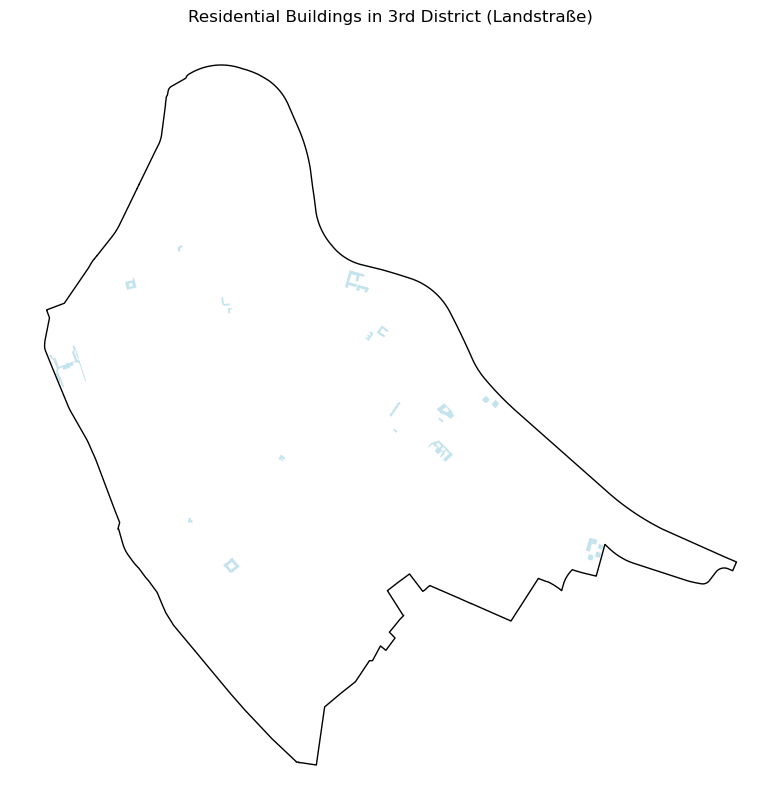

In [40]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

# STEP 1: Get residential buildings from OSM
residential_tags = {'building': ['residential']}
residential = ox.features_from_place('Vienna, Austria', tags=residential_tags)

# STEP 2: Load or filter Vienna's districts
# Filter for the 3rd district (Landstraße)
district_3rd = districts[districts['NAMEK'] == 'Landstraße']

# STEP 3: Align CRS and clean geometries
residential_cl = residential[residential.is_valid & ~residential.is_empty]
residential_cl = residential_cl.to_crs(district_3rd.crs)

# STEP 4: Clip residential buildings to 3rd district
residential_clipped = gpd.clip(residential_cl, district_3rd)

# Optional: plot the result
fig, ax = plt.subplots(figsize=(10, 10))
district_3rd.plot(ax=ax, color='none', edgecolor='black')
residential_clipped.plot(ax=ax, color='lightblue', alpha=0.7)
plt.title("Residential Buildings in 3rd District (Landstraße)")
plt.axis('off')
plt.show()

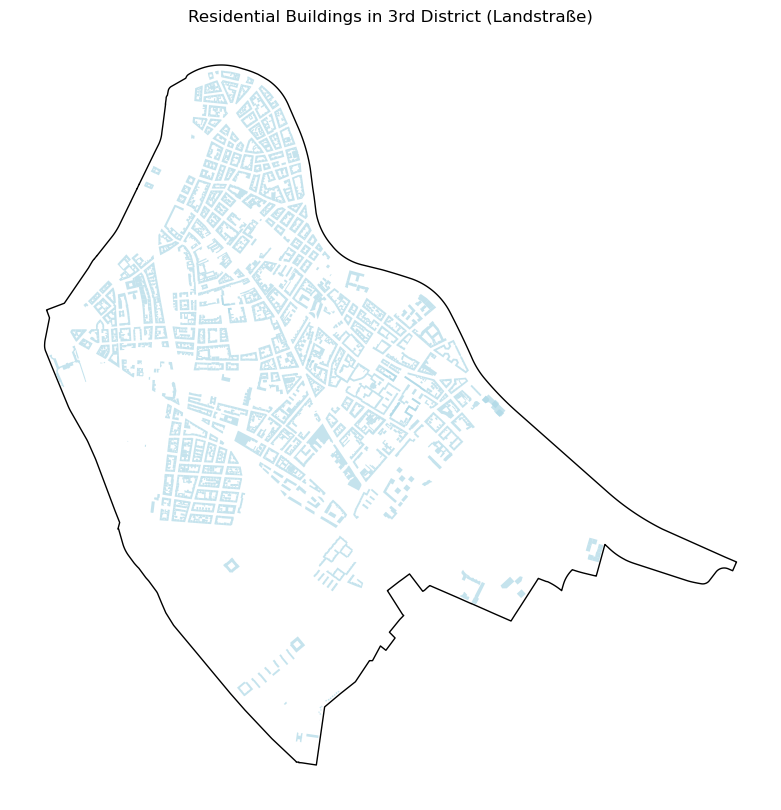

In [41]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

# STEP 1: Get residential buildings from OSM
residential_tags = {'building': ['residential', 'apartments', 'house', 'detached', 'terrace']}
residential = ox.features_from_place('Vienna, Austria', tags=residential_tags)

# STEP 2: Load or filter Vienna's districts
# Filter for the 3rd district (Landstraße)
district_3rd = districts[districts['NAMEK'] == 'Landstraße']

# STEP 3: Align CRS and clean geometries
residential_cl = residential[residential.is_valid & ~residential.is_empty]
residential_cl = residential_cl.to_crs(district_3rd.crs)

# STEP 4: Clip residential buildings to 3rd district
residential_clipped = gpd.clip(residential_cl, district_3rd)

# Optional: plot the result
fig, ax = plt.subplots(figsize=(10, 10))
district_3rd.plot(ax=ax, color='none', edgecolor='black')
residential_clipped.plot(ax=ax, color='lightblue', alpha=0.7)
plt.title("Residential Buildings in 3rd District (Landstraße)")
plt.axis('off')
plt.show()

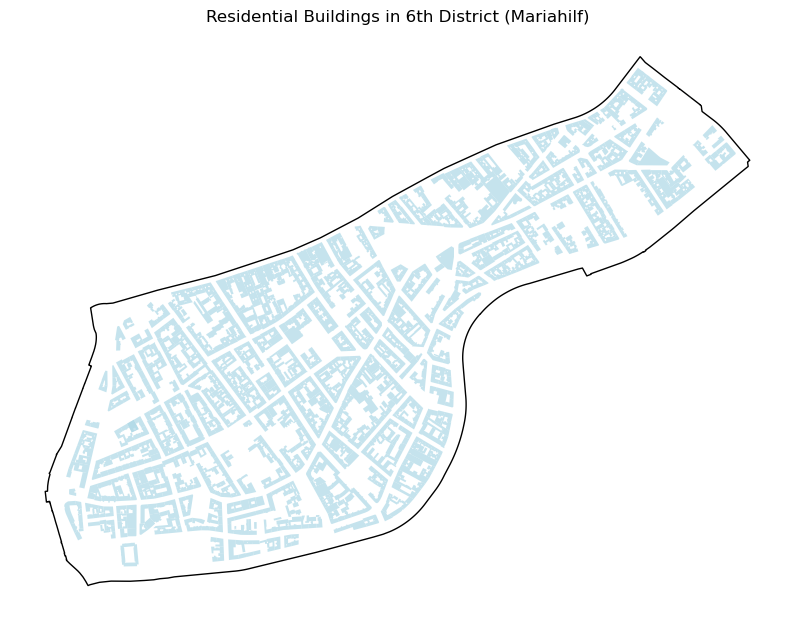

In [42]:
# STEP 2: Filter for the 6th district (Mariahilf)
district_6th = districts[districts['NAMEK'] == 'Mariahilf']

# STEP 3: Align CRS and clean geometries
residential_cl_6 = residential[residential.is_valid & ~residential.is_empty]
residential_cl_6 = residential_cl_6.to_crs(district_6th.crs)

# STEP 4: Clip residential buildings to the 6th district
residential_clipped_6 = gpd.clip(residential_cl_6, district_6th)

# Optional: plot the result
fig, ax = plt.subplots(figsize=(10, 10))
district_6th.plot(ax=ax, color='none', edgecolor='black')
residential_clipped_6.plot(ax=ax, color='lightblue', alpha=0.7)
plt.title("Residential Buildings in 6th District (Mariahilf)")
plt.axis('off')
plt.show()


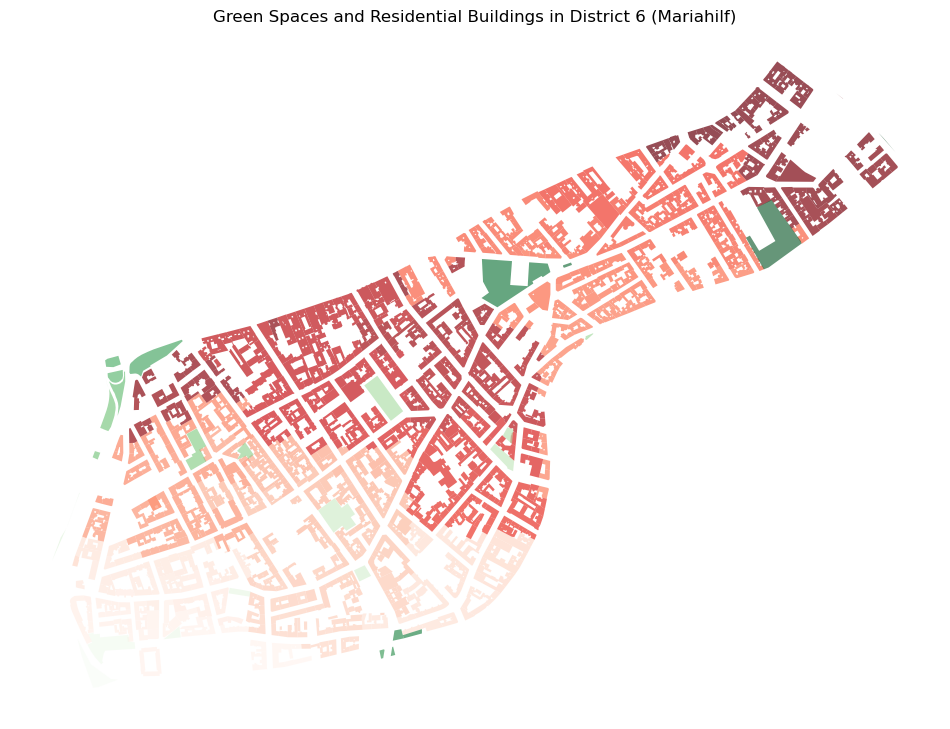

In [43]:
# STEP 1: Align CRS
gdf_green = gdf_green.to_crs(residential_clipped_6.crs)

# STEP 2: Clip green areas to 6th district
gdf_green_6 = gpd.clip(gdf_green, district_6th)

# STEP 3: Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
residential_clipped_6.plot(ax=ax, cmap='Reds', alpha=0.7)
gdf_green_6.plot(ax=ax, cmap='Greens', alpha=0.6)

ax.axis('off')
plt.title("Green Spaces and Residential Buildings in District 6 (Mariahilf)")
plt.show()


Total buildings: 1076
Within 300m: 1076
Percentage meeting WHO guideline: 100.00%


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/3343898225.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  green_union_6 = gdf_green_proj_6.unary_union
/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/3343898225.py:30: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  res_centroids_6[~res_centroids_6['within_300m']].plot(ax=ax, color='red', markersize=5, label='> 300m')


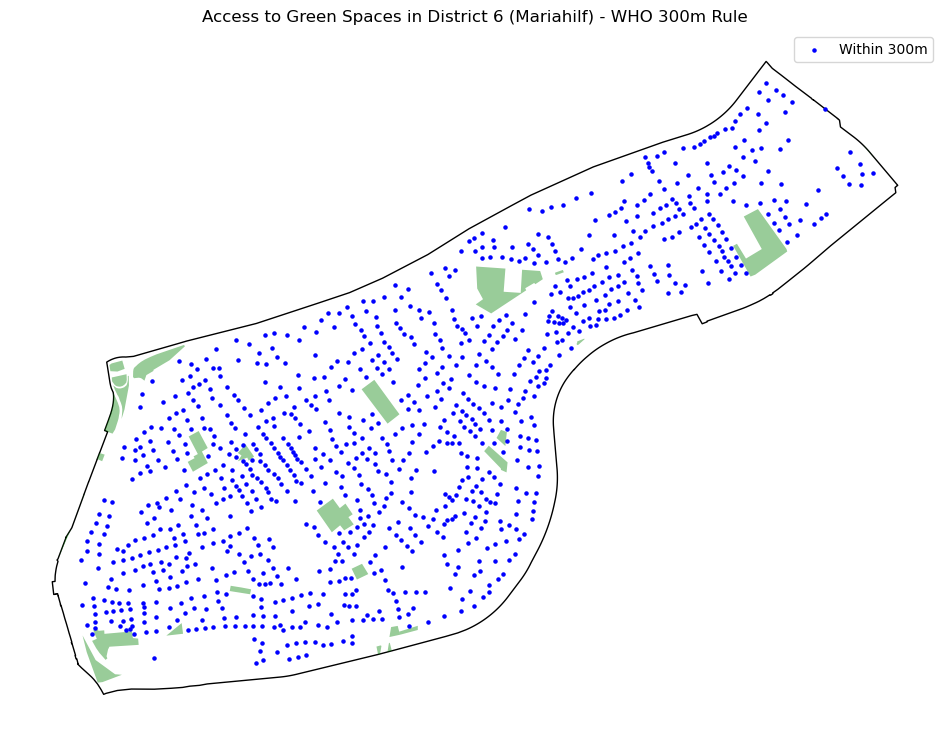

In [44]:
# STEP 0: Reproject to a projected CRS (for accurate distance in meters)
residential_proj_6 = residential_clipped_6.to_crs(epsg=31256)
gdf_green_proj_6 = gdf_green_6.to_crs(epsg=31256)

# STEP 1: Get centroids
res_centroids_6 = residential_proj_6.copy()
res_centroids_6['geometry'] = res_centroids_6.centroid

# STEP 2: Merge green areas
green_union_6 = gdf_green_proj_6.unary_union

# STEP 3: Calculate distances
res_centroids_6['distance_to_green'] = res_centroids_6.geometry.apply(lambda x: x.distance(green_union_6))
res_centroids_6['within_300m'] = res_centroids_6['distance_to_green'] <= 300

# STEP 4: Summary
total_buildings = len(res_centroids_6)
within_300m = res_centroids_6['within_300m'].sum()
percent = (within_300m / total_buildings) * 100

print(f"Total buildings: {total_buildings}")
print(f"Within 300m: {within_300m}")
print(f"Percentage meeting WHO guideline: {percent:.2f}%")

# STEP 5: Plot
fig, ax = plt.subplots(figsize=(12, 12))
district_6th.to_crs(epsg=31256).plot(ax=ax, color='none', edgecolor='black')
gdf_green_proj_6.plot(ax=ax, color='green', alpha=0.4)
res_centroids_6[res_centroids_6['within_300m']].plot(ax=ax, color='blue', markersize=5, label='Within 300m')
res_centroids_6[~res_centroids_6['within_300m']].plot(ax=ax, color='red', markersize=5, label='> 300m')
plt.title("Access to Green Spaces in District 6 (Mariahilf) - WHO 300m Rule")
plt.axis('off')
plt.legend()
plt.show()


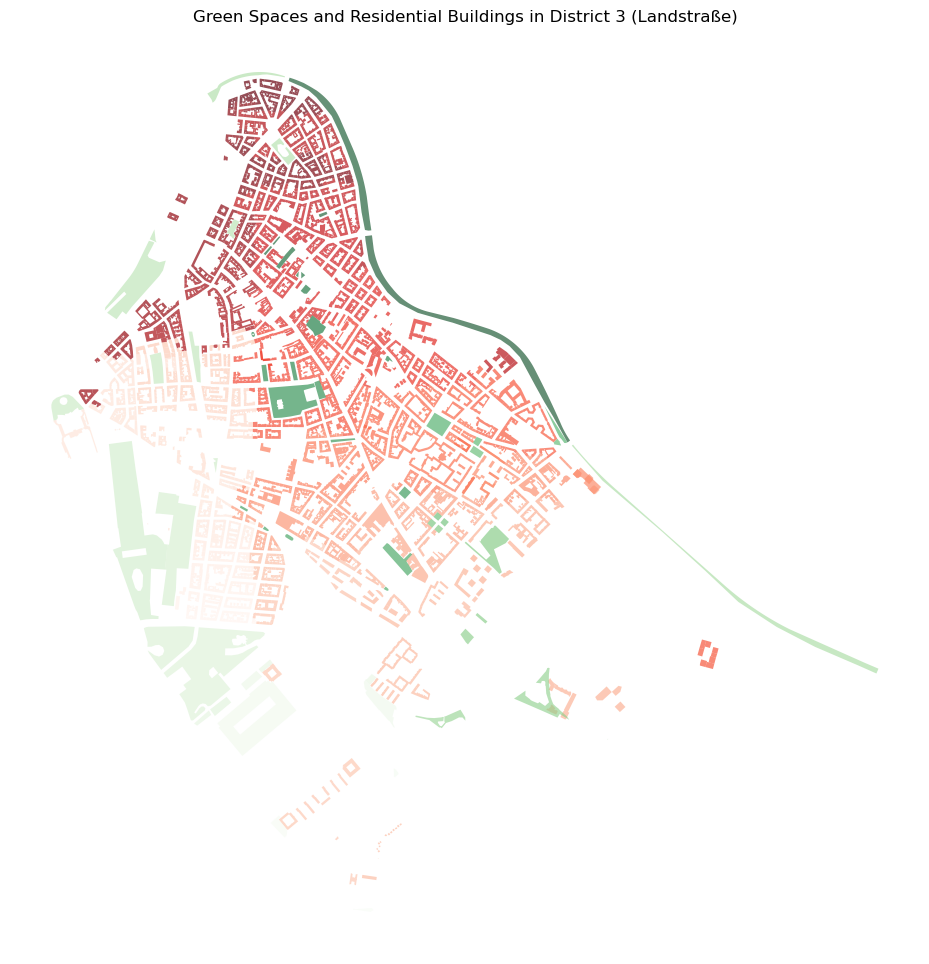

In [45]:
# STEP 1: Align CRS
gdf_green = gdf_green.to_crs(residential_clipped.crs)

# STEP 2: Clip green areas to 6th district
gdf_green_3 = gpd.clip(gdf_green, district_3rd)

# STEP 3: Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
residential_clipped.plot(ax=ax, cmap='Reds', alpha=0.7)
gdf_green_3.plot(ax=ax, cmap='Greens', alpha=0.6)

ax.axis('off')
plt.title("Green Spaces and Residential Buildings in District 3 (Landstraße)")
plt.show()


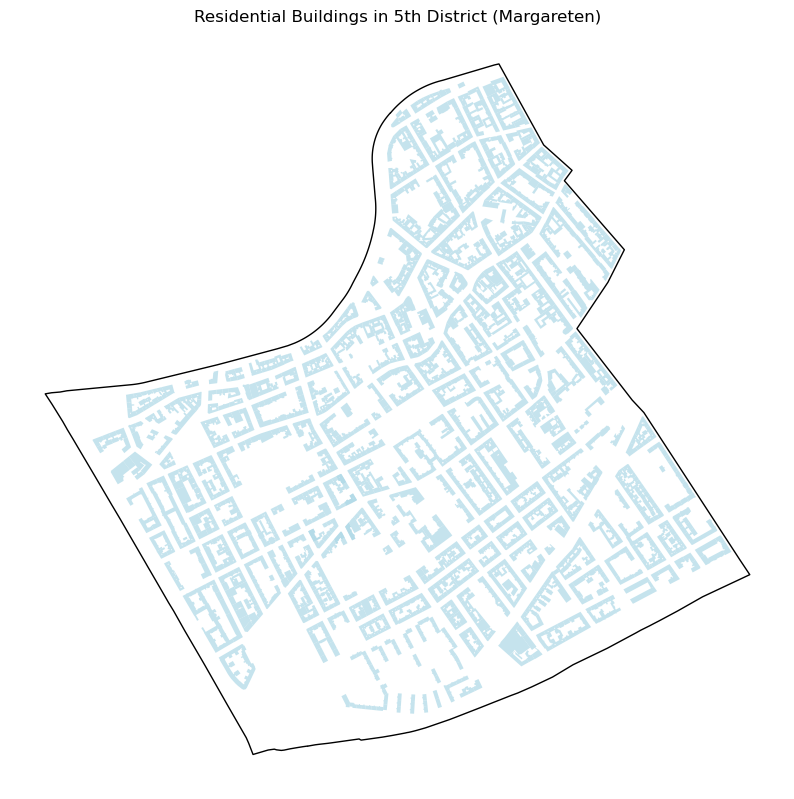

In [46]:
# STEP 2: Filter for the 5th district (Margareten)
district_5th = districts[districts['NAMEK'] == 'Margareten']

# STEP 3: Align CRS and clean geometries
residential_cl_5 = residential[residential.is_valid & ~residential.is_empty]
residential_cl_5 = residential_cl_5.to_crs(district_5th.crs)

# STEP 4: Clip residential buildings to the 5th district
residential_clipped_5 = gpd.clip(residential_cl_5, district_5th)

# Optional: plot the result
fig, ax = plt.subplots(figsize=(10, 10))
district_5th.plot(ax=ax, color='none', edgecolor='black')
residential_clipped_5.plot(ax=ax, color='lightblue', alpha=0.7)
plt.title("Residential Buildings in 5th District (Margareten)")
plt.axis('off')
plt.show()


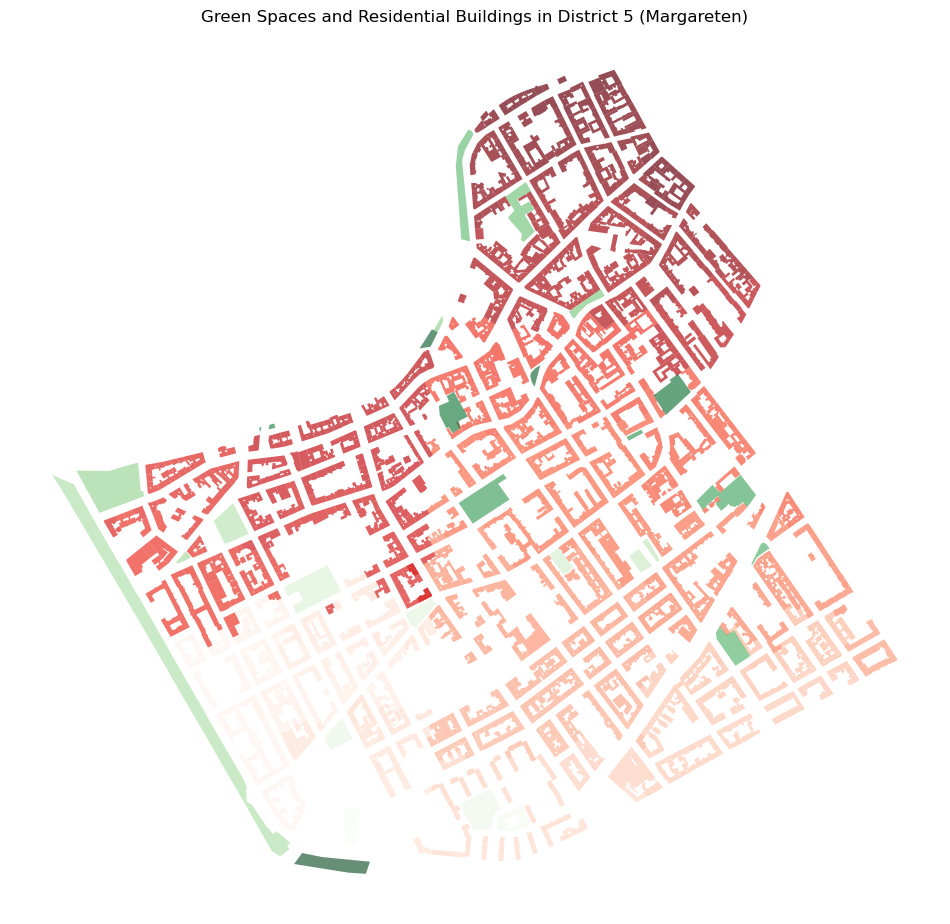

In [47]:
# STEP 1: Align CRS
gdf_green = gdf_green.to_crs(residential_clipped_5.crs)

# STEP 2: Clip green areas to 5th district
gdf_green_5 = gpd.clip(gdf_green, district_5th)

# STEP 3: Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
residential_clipped_5.plot(ax=ax, cmap='Reds', alpha=0.7)
gdf_green_5.plot(ax=ax, cmap='Greens', alpha=0.6)

ax.axis('off')
plt.title("Green Spaces and Residential Buildings in District 5 (Margareten)")
plt.show()


Total residential buildings in 5th district: 1433
Buildings within 300m of a green space: 1426
Percentage meeting WHO guideline: 99.51%


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/1918064458.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  green_union_5 = gdf_green_proj_5.unary_union


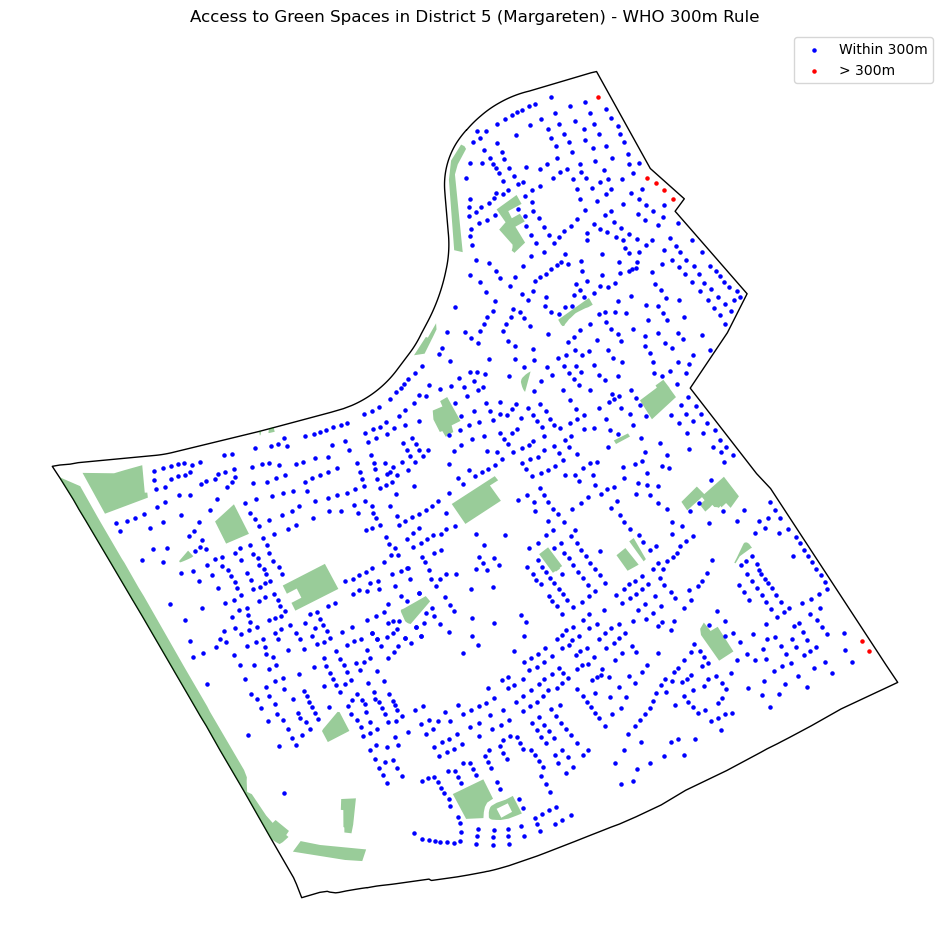

In [48]:
# STEP 0: Reproject to projected CRS for accurate metric distances
residential_proj_5 = residential_clipped_5.to_crs(epsg=31256)
gdf_green_proj_5 = gdf_green_5.to_crs(epsg=31256)

# STEP 1: Calculate centroids of residential buildings
res_centroids_5 = residential_proj_5.copy()
res_centroids_5['geometry'] = res_centroids_5.centroid

# STEP 2: Create a unified geometry of all green areas
green_union_5 = gdf_green_proj_5.unary_union

# STEP 3: Compute Euclidean distance to nearest green space
res_centroids_5['distance_to_green'] = res_centroids_5.geometry.apply(lambda x: x.distance(green_union_5))
res_centroids_5['within_300m'] = res_centroids_5['distance_to_green'] <= 300

# STEP 4: Summary statistics
total_buildings_5 = len(res_centroids_5)
within_300m_5 = res_centroids_5['within_300m'].sum()
percent_within_5 = (within_300m_5 / total_buildings_5) * 100

print(f"Total residential buildings in 5th district: {total_buildings_5}")
print(f"Buildings within 300m of a green space: {within_300m_5}")
print(f"Percentage meeting WHO guideline: {percent_within_5:.2f}%")

# STEP 5: Visualization
fig, ax = plt.subplots(figsize=(12, 12))
district_5th.to_crs(epsg=31256).plot(ax=ax, color='none', edgecolor='black')
gdf_green_proj_5.plot(ax=ax, color='green', alpha=0.4)
res_centroids_5[res_centroids_5['within_300m']].plot(ax=ax, color='blue', markersize=5, label='Within 300m')
res_centroids_5[~res_centroids_5['within_300m']].plot(ax=ax, color='red', markersize=5, label='> 300m')
plt.title("Access to Green Spaces in District 5 (Margareten) - WHO 300m Rule")
plt.axis('off')
plt.legend()
plt.show()


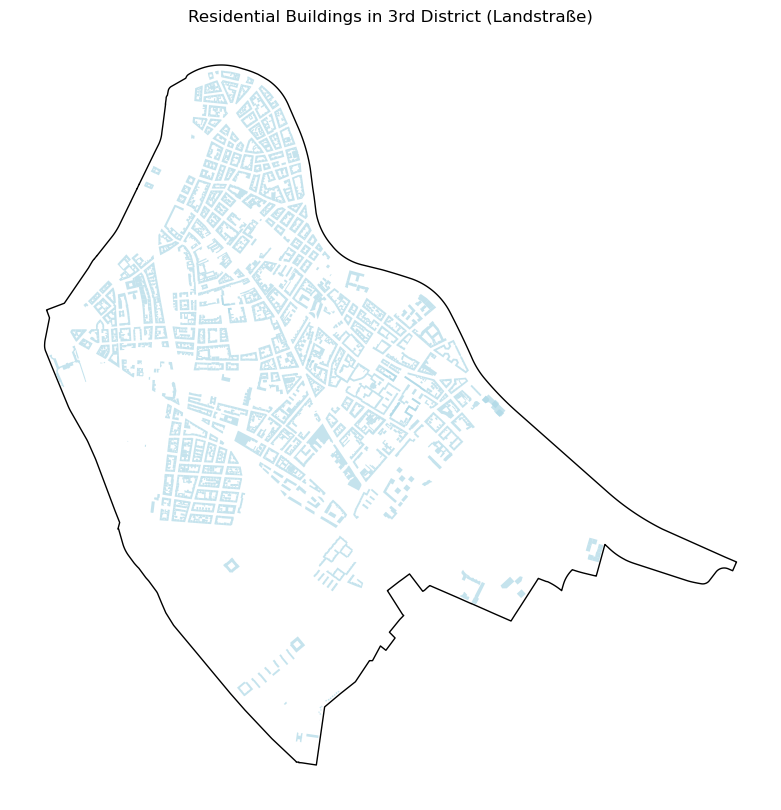

In [49]:
# STEP 2: Filter for the 3rd district (Landstraße)
district_3rd = districts[districts['NAMEK'] == 'Landstraße']

# STEP 3: Align CRS and clean geometries
residential_cl_3 = residential[residential.is_valid & ~residential.is_empty]
residential_cl_3 = residential_cl_3.to_crs(district_3rd.crs)

# STEP 4: Clip residential buildings to the 3rd district
residential_clipped_3 = gpd.clip(residential_cl_3, district_3rd)

# Optional: plot the result
fig, ax = plt.subplots(figsize=(10, 10))
district_3rd.plot(ax=ax, color='none', edgecolor='black')
residential_clipped_3.plot(ax=ax, color='lightblue', alpha=0.7)
plt.title("Residential Buildings in 3rd District (Landstraße)")
plt.axis('off')
plt.show()


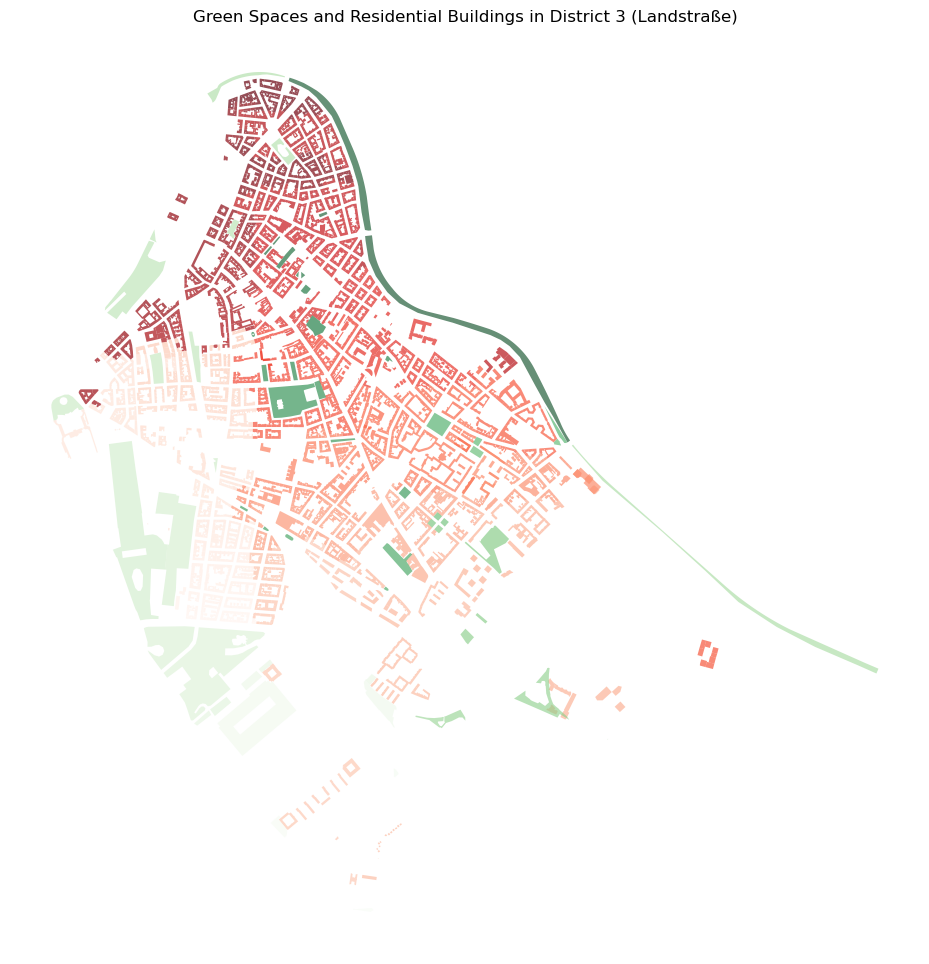

In [50]:
# STEP 1: Align CRS
gdf_green = gdf_green.to_crs(residential_clipped_3.crs)

# STEP 2: Clip green areas to 3rd district
gdf_green_3 = gpd.clip(gdf_green, district_3rd)

# STEP 3: Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
residential_clipped_3.plot(ax=ax, cmap='Reds', alpha=0.7)
gdf_green_3.plot(ax=ax, cmap='Greens', alpha=0.6)

ax.axis('off')
plt.title("Green Spaces and Residential Buildings in District 3 (Landstraße)")
plt.show()


Total residential buildings in 3rd district: 2482
Buildings within 300m of a green space: 2474
Percentage meeting WHO guideline: 99.68%


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/3364334082.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  green_union_3 = gdf_green_proj_3.unary_union


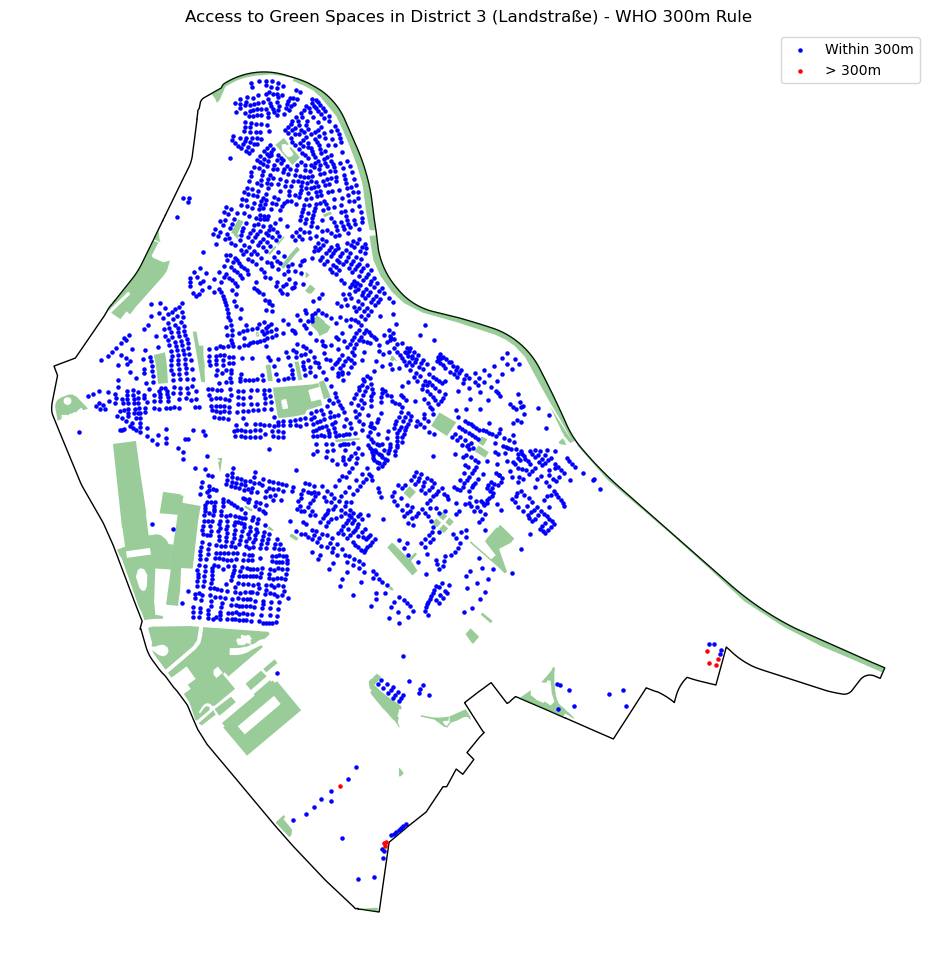

In [51]:
# STEP 0: Reproject to projected CRS for accurate metric distances
residential_proj_3 = residential_clipped_3.to_crs(epsg=31256)
gdf_green_proj_3 = gdf_green_3.to_crs(epsg=31256)

# STEP 1: Calculate centroids of residential buildings
res_centroids_3 = residential_proj_3.copy()
res_centroids_3['geometry'] = res_centroids_3.centroid

# STEP 2: Create a unified geometry of all green areas
green_union_3 = gdf_green_proj_3.unary_union

# STEP 3: Compute Euclidean distance to nearest green space
res_centroids_3['distance_to_green'] = res_centroids_3.geometry.apply(lambda x: x.distance(green_union_3))
res_centroids_3['within_300m'] = res_centroids_3['distance_to_green'] <= 300

# STEP 4: Summary statistics
total_buildings_3 = len(res_centroids_3)
within_300m_3 = res_centroids_3['within_300m'].sum()
percent_within_3 = (within_300m_3 / total_buildings_3) * 100

print(f"Total residential buildings in 3rd district: {total_buildings_3}")
print(f"Buildings within 300m of a green space: {within_300m_3}")
print(f"Percentage meeting WHO guideline: {percent_within_3:.2f}%")

# STEP 5: Visualization
fig, ax = plt.subplots(figsize=(12, 12))
district_3rd.to_crs(epsg=31256).plot(ax=ax, color='none', edgecolor='black')
gdf_green_proj_3.plot(ax=ax, color='green', alpha=0.4)
res_centroids_3[res_centroids_3['within_300m']].plot(ax=ax, color='blue', markersize=5, label='Within 300m')
res_centroids_3[~res_centroids_3['within_300m']].plot(ax=ax, color='red', markersize=5, label='> 300m')
plt.title("Access to Green Spaces in District 3 (Landstraße) - WHO 300m Rule")
plt.axis('off')
plt.legend()
plt.show()


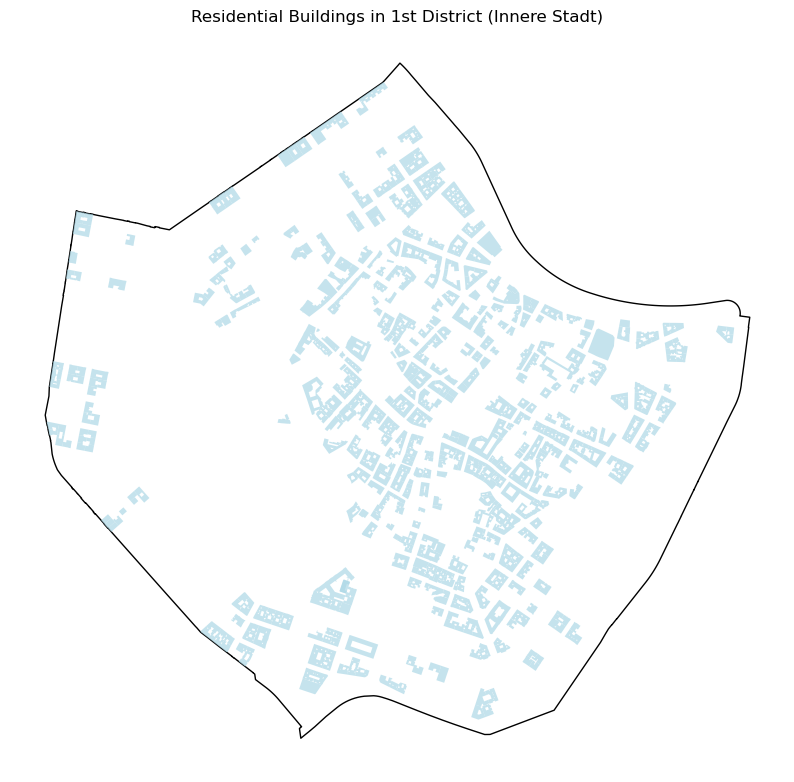

In [52]:
# STEP 2: Filter for the 1st district (Innere Stadt)
district_1st = districts[districts['NAMEK'] == 'Innere Stadt']

# STEP 3: Align CRS and clean geometries
residential_cl_1 = residential[residential.is_valid & ~residential.is_empty]
residential_cl_1 = residential_cl_1.to_crs(district_1st.crs)

# STEP 4: Clip residential buildings to the 1st district
residential_clipped_1 = gpd.clip(residential_cl_1, district_1st)

# Optional: plot the result
fig, ax = plt.subplots(figsize=(10, 10))
district_1st.plot(ax=ax, color='none', edgecolor='black')
residential_clipped_1.plot(ax=ax, color='lightblue', alpha=0.7)
plt.title("Residential Buildings in 1st District (Innere Stadt)")
plt.axis('off')
plt.show()

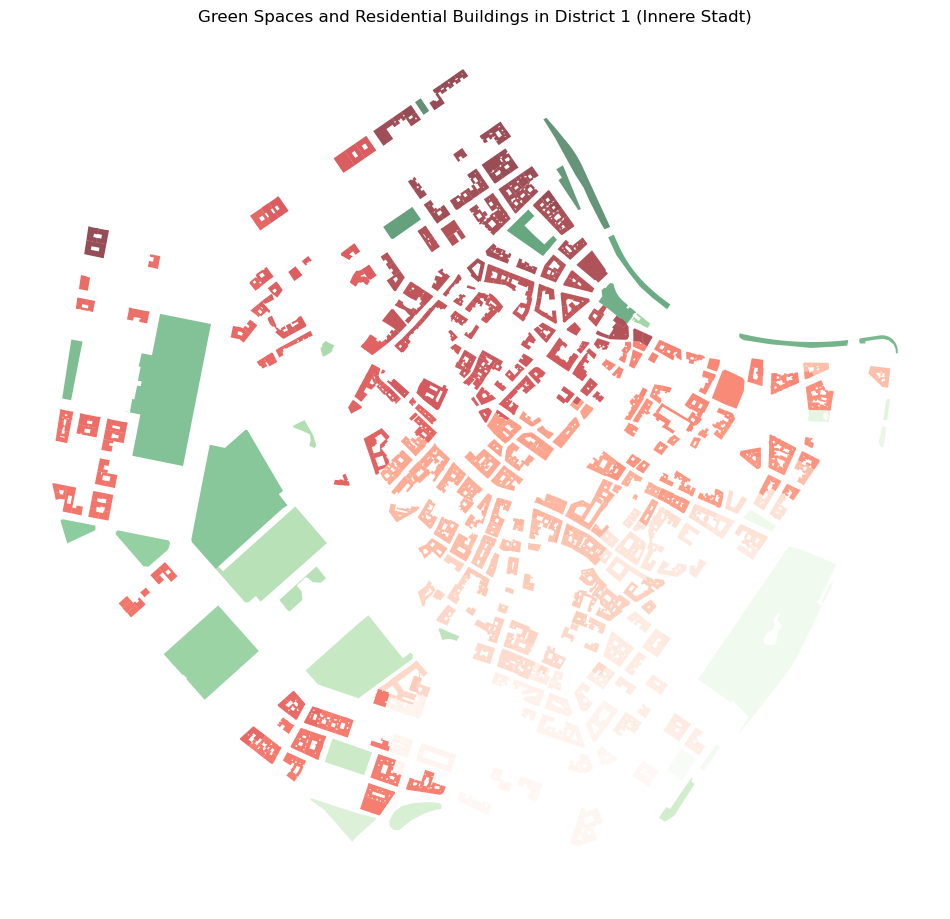

In [53]:
# STEP 1: Align CRS
gdf_green = gdf_green.to_crs(residential_clipped_1.crs)

# STEP 2: Clip green areas to 1st district
gdf_green_1 = gpd.clip(gdf_green, district_1st)

# STEP 3: Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
residential_clipped_1.plot(ax=ax, cmap='Reds', alpha=0.7)
gdf_green_1.plot(ax=ax, cmap='Greens', alpha=0.6)

ax.axis('off')
plt.title("Green Spaces and Residential Buildings in District 1 (Innere Stadt)")
plt.show()


Total residential buildings in 1st district: 749
Buildings within 300m of a green space: 618
Percentage meeting WHO guideline: 82.51%


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/3218082943.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  green_union_1 = gdf_green_proj_1.unary_union


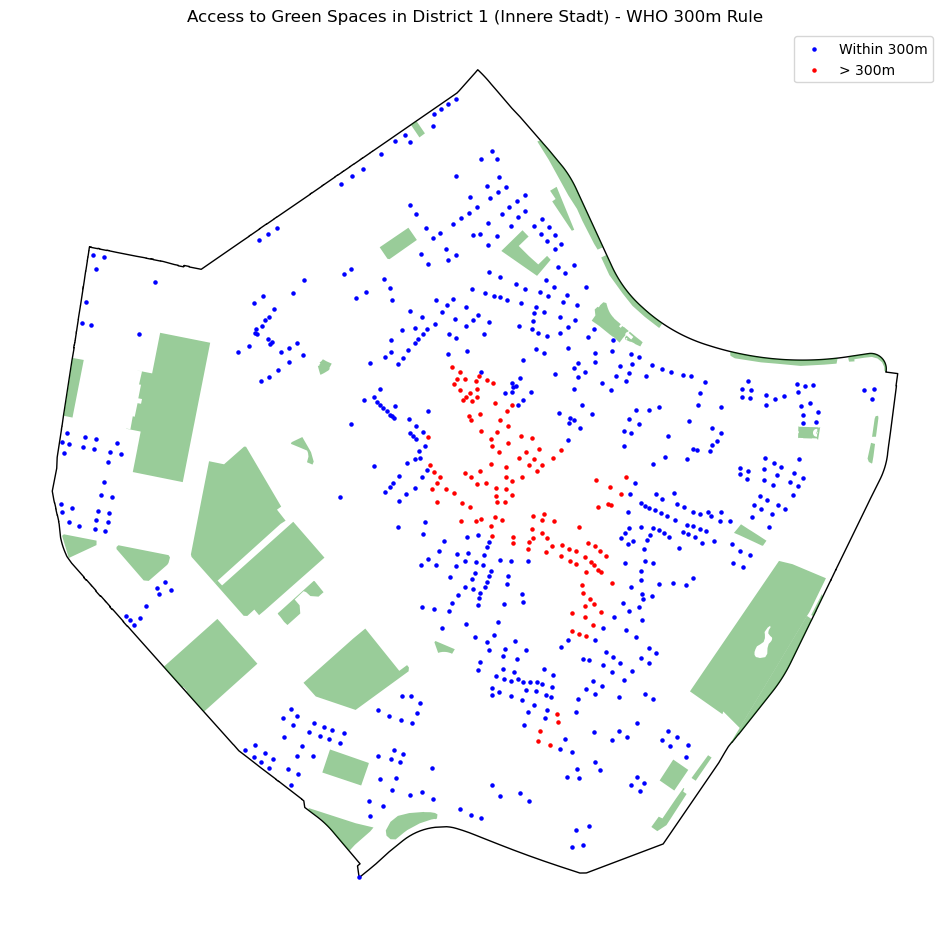

In [54]:
# STEP 0: Reproject both layers for accurate distance calculations (EPSG:31256 for Vienna)
residential_proj_1 = residential_clipped_1.to_crs(epsg=31256)
gdf_green_proj_1 = gdf_green_1.to_crs(epsg=31256)

# STEP 1: Calculate centroids of residential buildings
res_centroids_1 = residential_proj_1.copy()
res_centroids_1['geometry'] = res_centroids_1.centroid

# STEP 2: Create a unified green space geometry
green_union_1 = gdf_green_proj_1.unary_union

# STEP 3: Compute distance from each building to nearest green space
res_centroids_1['distance_to_green'] = res_centroids_1.geometry.apply(lambda x: x.distance(green_union_1))
res_centroids_1['within_300m'] = res_centroids_1['distance_to_green'] <= 300

# STEP 4: Summary stats
total_buildings_1 = len(res_centroids_1)
within_300m_1 = res_centroids_1['within_300m'].sum()
percent_within_1 = (within_300m_1 / total_buildings_1) * 100

print(f"Total residential buildings in 1st district: {total_buildings_1}")
print(f"Buildings within 300m of a green space: {within_300m_1}")
print(f"Percentage meeting WHO guideline: {percent_within_1:.2f}%")

# STEP 5: Visualization
fig, ax = plt.subplots(figsize=(12, 12))
district_1st.to_crs(epsg=31256).plot(ax=ax, color='none', edgecolor='black')
gdf_green_proj_1.plot(ax=ax, color='green', alpha=0.4)
res_centroids_1[res_centroids_1['within_300m']].plot(ax=ax, color='blue', markersize=5, label='Within 300m')
res_centroids_1[~res_centroids_1['within_300m']].plot(ax=ax, color='red', markersize=5, label='> 300m')
plt.title("Access to Green Spaces in District 1 (Innere Stadt) - WHO 300m Rule")
plt.axis('off')
plt.legend()
plt.show()


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/2393924758.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  green_union_1 = gdf_green_proj_1.unary_union


Total residential buildings in 1st district: 749
Buildings within 300m of a green space: 618
Percentage meeting WHO guideline: 82.51%


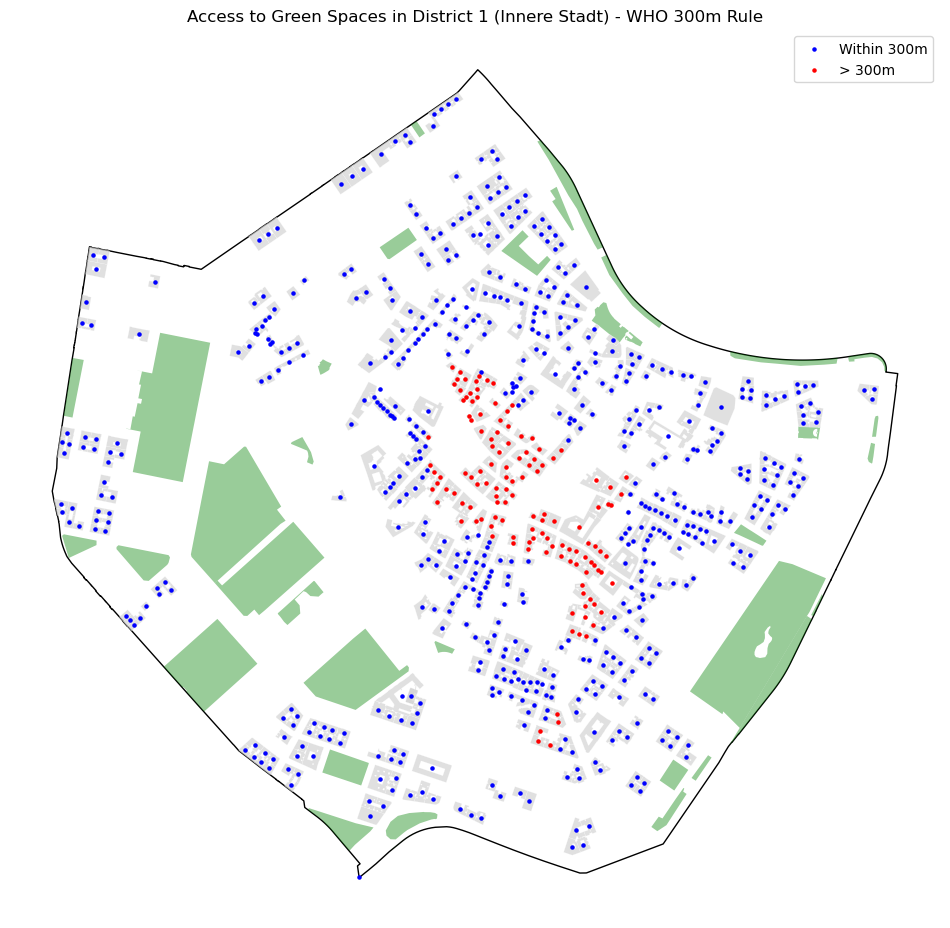

In [55]:
# STEP 0: Reproject both layers for accurate distance calculations (EPSG:31256 for Vienna)
residential_proj_1 = residential_clipped_1.to_crs(epsg=31256)
gdf_green_proj_1 = gdf_green_1.to_crs(epsg=31256)

# STEP 1: Calculate centroids of residential buildings
res_centroids_1 = residential_proj_1.copy()
res_centroids_1['geometry'] = res_centroids_1.centroid

# STEP 2: Create a unified green space geometry
green_union_1 = gdf_green_proj_1.unary_union

# STEP 3: Compute distance from each building to nearest green space
res_centroids_1['distance_to_green'] = res_centroids_1.geometry.apply(lambda x: x.distance(green_union_1))
res_centroids_1['within_300m'] = res_centroids_1['distance_to_green'] <= 300

# STEP 4: Summary stats
total_buildings_1 = len(res_centroids_1)
within_300m_1 = res_centroids_1['within_300m'].sum()
percent_within_1 = (within_300m_1 / total_buildings_1) * 100

print(f"Total residential buildings in 1st district: {total_buildings_1}")
print(f"Buildings within 300m of a green space: {within_300m_1}")
print(f"Percentage meeting WHO guideline: {percent_within_1:.2f}%")

# STEP 5: Visualization with building silhouettes
fig, ax = plt.subplots(figsize=(12, 12))

# District boundary
district_1st.to_crs(epsg=31256).plot(ax=ax, color='none', edgecolor='black')

# Green spaces
gdf_green_proj_1.plot(ax=ax, color='green', alpha=0.4)

# Building footprints
residential_proj_1.plot(ax=ax, color='lightgray', alpha=0.7, edgecolor='white', linewidth=0.2)

# Centroids as dots
res_centroids_1[res_centroids_1['within_300m']].plot(ax=ax, color='blue', markersize=5, label='Within 300m')
res_centroids_1[~res_centroids_1['within_300m']].plot(ax=ax, color='red', markersize=5, label='> 300m')

plt.title("Access to Green Spaces in District 1 (Innere Stadt) - WHO 300m Rule")
plt.axis('off')
plt.legend()
plt.show()



--- Processing District 6: Mariahilf ---
Total residential buildings: 1076
Within 300m of green space: 1076
Percentage compliant with WHO guideline: 100.00%


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/2467977244.py:73: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  res_centroids[~res_centroids['within_300m']].plot(ax=ax, color='red', markersize=5, label='> 300m')


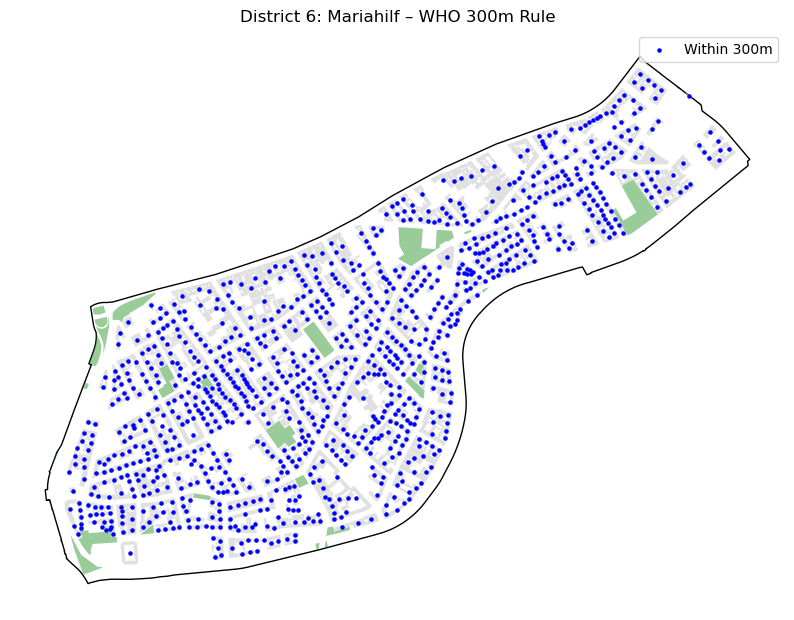


--- Processing District 5: Margareten ---
Total residential buildings: 1433
Within 300m of green space: 1426
Percentage compliant with WHO guideline: 99.51%


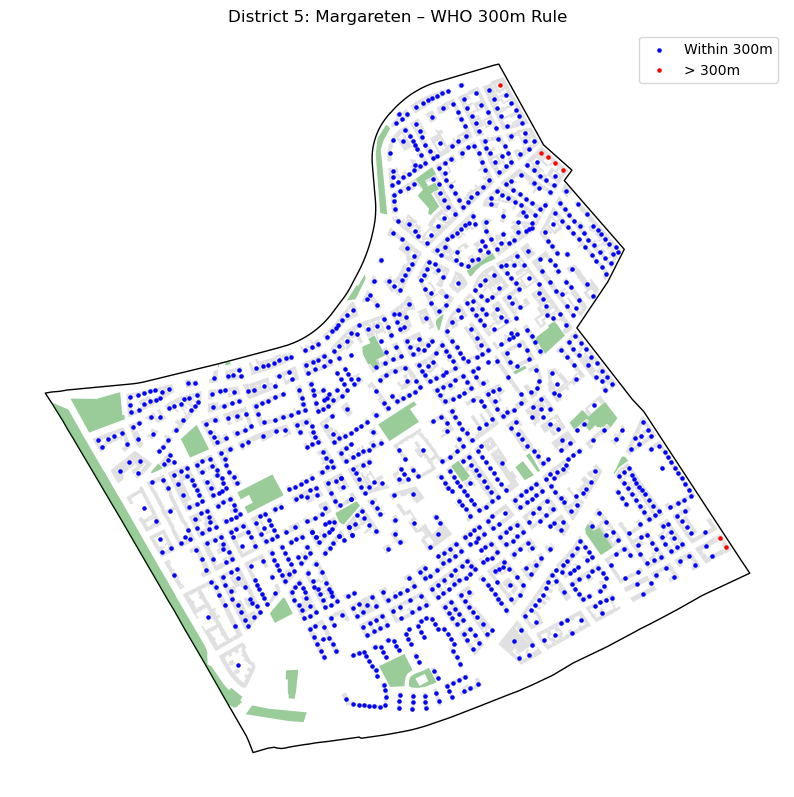


--- Processing District 3: Landstraße ---
Total residential buildings: 2482
Within 300m of green space: 2474
Percentage compliant with WHO guideline: 99.68%


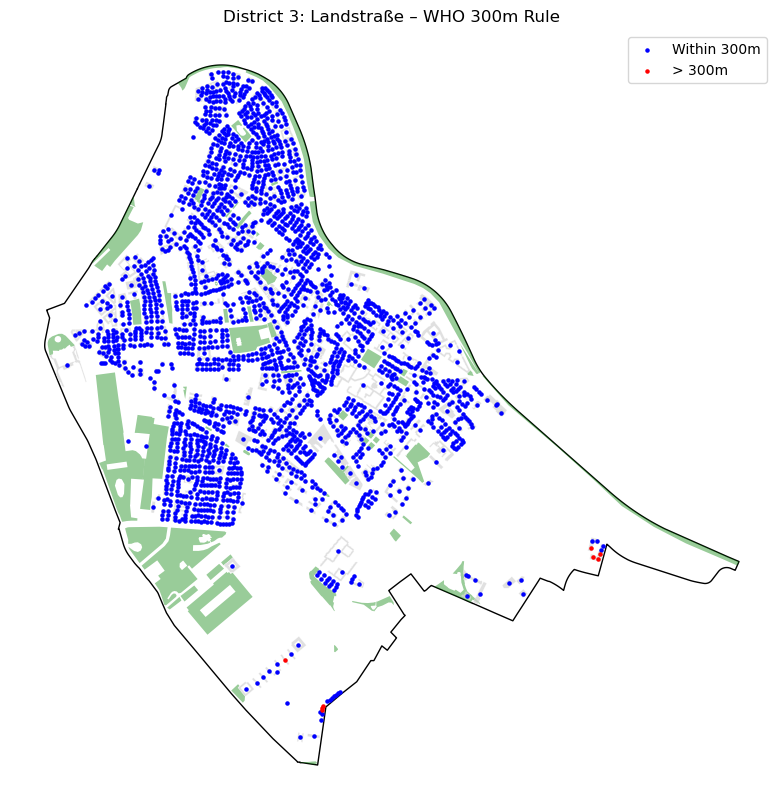


--- Processing District 1: Innere Stadt ---
Total residential buildings: 749
Within 300m of green space: 618
Percentage compliant with WHO guideline: 82.51%


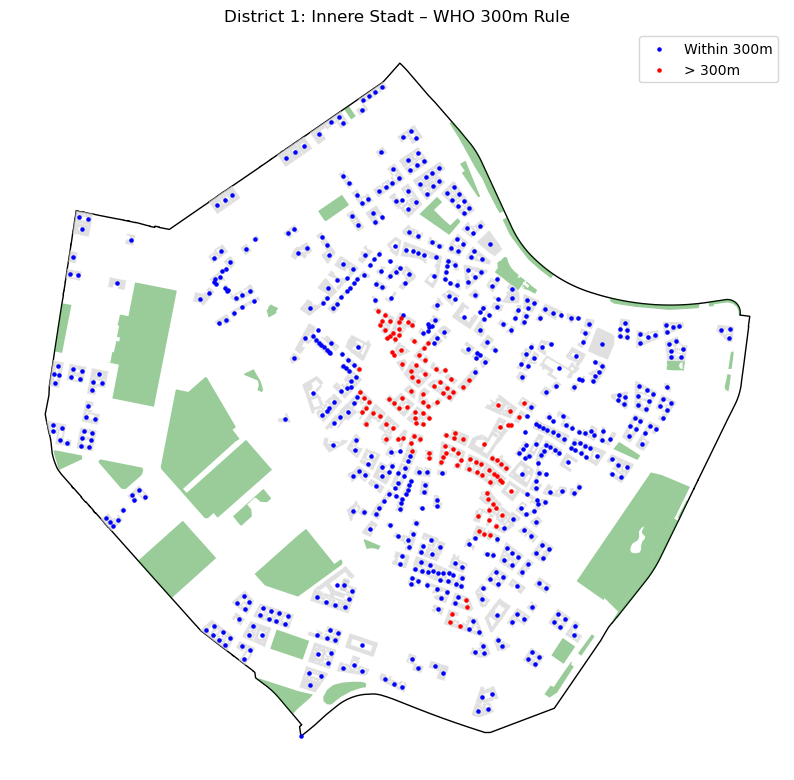

In [56]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
from shapely.ops import unary_union

# Define target districts (number: name)
target_districts = {
    6: 'Mariahilf',
    5: 'Margareten',
    3: 'Landstraße',
    1: 'Innere Stadt'
}

# Load all residential buildings once
residential_tags = {'building': ['residential', 'apartments', 'house', 'detached', 'terrace']}
residential_all = ox.features_from_place('Vienna, Austria', tags=residential_tags)

# Make sure districts and green space data are loaded:
# districts = gpd.read_file('vienna_districts.shp')
# gdf_green = ox.features_from_place('Vienna, Austria', tags={'leisure': 'park'})

# Loop through each district
for num, name in target_districts.items():
    print(f"\n--- Processing District {num}: {name} ---")

    # Filter the district
    district = districts[districts['NAMEK'] == name]
    if district.empty:
        print(f"District '{name}' not found in districts GeoDataFrame.")
        continue

    # Clean and align residential building data
    residential = residential_all[residential_all.is_valid & ~residential_all.is_empty]
    residential = residential.to_crs(district.crs)
    green = gdf_green.to_crs(district.crs)

    # Clip to district
    residential_clipped = gpd.clip(residential, district)
    green_clipped = gpd.clip(green, district)

    # Reproject to projected CRS (for distance in meters)
    crs_proj = 31256
    residential_proj = residential_clipped.to_crs(epsg=crs_proj)
    green_proj = green_clipped.to_crs(epsg=crs_proj)
    district_proj = district.to_crs(epsg=crs_proj)

    # Calculate centroids
    res_centroids = residential_proj.copy()
    res_centroids['geometry'] = res_centroids.centroid

    # Union of green spaces
    green_union = unary_union(green_proj.geometry)

    # Calculate distance and WHO compliance
    res_centroids['distance_to_green'] = res_centroids.geometry.apply(lambda x: x.distance(green_union))
    res_centroids['within_300m'] = res_centroids['distance_to_green'] <= 300

    # Stats
    total = len(res_centroids)
    within = res_centroids['within_300m'].sum()
    percent = (within / total) * 100 if total > 0 else 0

    print(f"Total residential buildings: {total}")
    print(f"Within 300m of green space: {within}")
    print(f"Percentage compliant with WHO guideline: {percent:.2f}%")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    district_proj.plot(ax=ax, color='none', edgecolor='black')
    green_proj.plot(ax=ax, color='green', alpha=0.4)
    residential_proj.plot(ax=ax, color='lightgray', alpha=0.7, edgecolor='white', linewidth=0.2)
    res_centroids[res_centroids['within_300m']].plot(ax=ax, color='blue', markersize=5, label='Within 300m')
    res_centroids[~res_centroids['within_300m']].plot(ax=ax, color='red', markersize=5, label='> 300m')
    plt.title(f"District {num}: {name} – WHO 300m Rule")
    plt.axis('off')
    plt.legend()
    plt.show()


In [57]:
# import geopandas as gpd
# import osmnx as ox
# import matplotlib.pyplot as plt
# from shapely.ops import unary_union

# STEP 1: Get residential buildings across Vienna
residential_tags = {'building': ['residential', 'apartments', 'house', 'detached', 'terrace']}
residential_all = ox.features_from_place('Vienna, Austria', tags=residential_tags)

# # STEP 2: Get green spaces across Vienna (e.g., parks, gardens, grass)
# green_tags = {
#     'leisure': ['park', 'garden'],
#     'landuse': ['grass', 'recreation_ground'],
#     'natural': ['wood']
# }
# gdf_green = ox.features_from_place('Vienna, Austria', tags=green_tags)

# STEP 3: Create a city-wide Vienna boundary from districts
vienna_boundary = districts.unary_union
vienna_gdf = gpd.GeoDataFrame(geometry=[vienna_boundary], crs=districts.crs)

# STEP 4: Clean and clip residential and green data to Vienna boundary
residential_all = residential_all[residential_all.is_valid & ~residential_all.is_empty]
gdf_green = gdf_green[gdf_green.is_valid & ~gdf_green.is_empty]

residential_vienna = gpd.clip(residential_all, vienna_gdf)
green_vienna = gpd.clip(gdf_green, vienna_gdf)

# STEP 5: Reproject all to EPSG:31256 (metric units for distance)
crs_proj = 31256
residential_proj = residential_vienna.to_crs(epsg=crs_proj)
green_proj = green_vienna.to_crs(epsg=crs_proj)
vienna_gdf_proj = vienna_gdf.to_crs(epsg=crs_proj)

# STEP 6: Calculate centroids of residential buildings
res_centroids = residential_proj.copy()
res_centroids['geometry'] = res_centroids.centroid

# STEP 7: Union all green space geometries
green_union = unary_union(green_proj.geometry)

# STEP 8: Calculate distance to nearest green space
res_centroids['distance_to_green'] = res_centroids.geometry.apply(lambda x: x.distance(green_union))
res_centroids['within_300m'] = res_centroids['distance_to_green'] <= 300

# STEP 9: Stats
total = len(res_centroids)
within = res_centroids['within_300m'].sum()
percent = (within / total) * 100 if total > 0 else 0

print("\n--- WHO 300m Rule for Vienna ---")
print(f"Total residential buildings: {total}")
print(f"Within 300m of green space: {within}")
print(f"Percentage compliant with WHO guideline: {percent:.2f}%")

/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/1311328520.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  vienna_boundary = districts.unary_union



--- WHO 300m Rule for Vienna ---
Total residential buildings: 66085
Within 300m of green space: 62166
Percentage compliant with WHO guideline: 94.07%


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_14960/2093387027.py:20: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


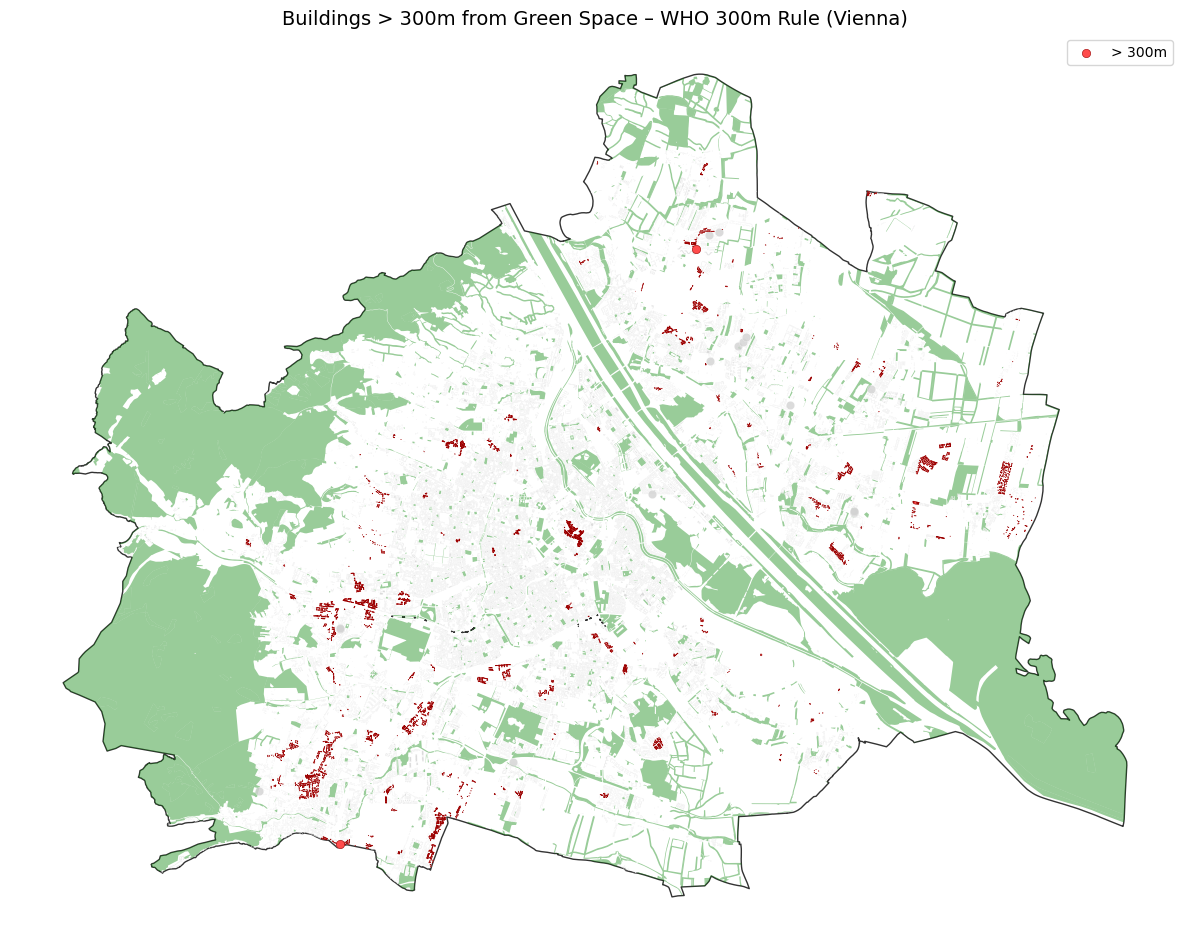

In [58]:
# STEP 10: Brighter plot
fig, ax = plt.subplots(figsize=(12, 12))

# Outline of Vienna
vienna_gdf_proj.plot(ax=ax, color='none', edgecolor='#333333')

# Brighter green areas
green_proj.plot(ax=ax, color='green', alpha=0.4)

# All buildings in light gray
residential_proj.plot(ax=ax, color='#D3D3D3', alpha=0.8, edgecolor='white', linewidth=0.2)

# Highlight non-compliant buildings in bright red
non_compliant_buildings = residential_proj[~res_centroids['within_300m'].values]
non_compliant_buildings.plot(ax=ax, color='#FF4C4C', edgecolor='#990000', linewidth=0.4, label='> 300m')

# Title and legend
plt.title("Buildings > 300m from Green Space – WHO 300m Rule (Vienna)", fontsize=14)
plt.axis('off')
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig("output/vienna_who_300m_noncompliant_bright.png", dpi=300, bbox_inches='tight')
plt.show()


In [77]:
import h3
print(h3.__version__)
print(hasattr(h3, 'polyfill'))  

4.2.2
False


In [78]:
import h3.api.basic_int as h3
from shapely.geometry import Polygon
import geopandas as gpd

def split_poly_to_hexagons(admin_gdf, resolution, crs):
    """
    Given a GeoDataFrame with a polygon (e.g. Vienna), return a GeoDataFrame
    of H3 hexagons covering that area.

    Parameters:
    - admin_gdf: GeoDataFrame with a single Polygon
    - resolution: H3 resolution level (int, e.g., 8 or 9)
    - crs: target CRS (e.g. 'EPSG:4326' or 'EPSG:31256')

    Returns:
    - GeoDataFrame with columns ['hex_id', 'geometry']
    """
    
    # Ensure geometry is in lat/lon (EPSG:4326) for H3 compatibility
    admin_gdf = admin_gdf.to_crs("EPSG:4326")

    # Extract coordinates for GeoJSON
    coords = list(admin_gdf.geometry.iloc[0].exterior.coords)
    admin_geojson = {"type": "Polygon", "coordinates": [coords]}

    # Generate H3 hexagons
    hex_ids = h3.polyfill_geojson(admin_geojson, resolution)

    # Convert to shapely Polygons
    hex_geoms = {
        hex_id: Polygon(h3.h3_to_geo_boundary(hex_id, geo_json=True))
        for hex_id in hex_ids
    }

    # Create GeoDataFrame
    hex_gdf = gpd.GeoDataFrame(
        hex_geoms.items(), columns=["hex_id", "geometry"], crs="EPSG:4326"
    )

    # Reproject to desired CRS
    return hex_gdf.to_crs(crs)


In [74]:
def split_poly_to_hexagons(admin_gdf, resolution, crs):
    
    coords = list(admin_gdf.geometry.to_list()[0].exterior.coords)
    admin_geojson = {"type": "Polygon",  "coordinates": [coords]}
    hexagons = h3.polyfill_geojson(admin_geojson, 
                           resolution, 
                           geo_json_conformant=True)
    
    hexagon_geometries = {hex_id: Polygon(h3.h3_to_geo_boundary(hex_id, \
                                geo_json=True)) for hex_id in hexagons}
    gdf_hexagon_geometries = gpd.GeoDataFrame(hexagon_geometries.items(), 
                                    columns=['hex_id', 'geometry'])
    gdf_hexagon_geometries.crs = crs
    
    return gdf_hexagon_geometries

In [79]:
import h3
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# STEP 1: Generate H3 hexagons for Vienna
vienna_proj = vienna_gdf.to_crs(epsg=4326)  # H3 expects lat/lon
hex_gdf = split_poly_to_hexagons(vienna_proj, resolution=9, crs="EPSG:4326")

# STEP 2: Reproject both hexes and non-compliant buildings to common CRS
hex_gdf_proj = hex_gdf.to_crs(epsg=31256)
noncompliant_proj = residential_proj[~res_centroids['within_300m'].values]

# STEP 3: Spatial join – assign buildings to H3 hexagons
join_hex = gpd.sjoin(hex_gdf_proj, noncompliant_proj, how="left", predicate="contains")

# STEP 4: Count buildings per hex
counts = join_hex.groupby('hex_id').size()
hex_gdf_proj['noncompliant_count'] = hex_gdf_proj['hex_id'].map(counts).fillna(0)

# STEP 5: Plot
fig, ax = plt.subplots(figsize=(9, 9))
hex_gdf_proj.plot(
    ax=ax,
    column='noncompliant_count',
    cmap='Reds',
    edgecolor='white',
    linewidth=0.2,
    legend=True,
    legend_kwds={'label': 'Non-Compliant Buildings per Hex'}
)
green_proj.plot(ax=ax, color='#90EE90', alpha=0.2)
vienna_gdf.to_crs(epsg=31256).plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)

plt.title('WHO 300m Rule – Non-Compliant Buildings (H3 Hex Map)', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.savefig('output/vienna_noncompliant_h3_hexmap.png', dpi=300, bbox_inches='tight')
plt.show()


AttributeError: module 'h3' has no attribute 'polyfill_geojson'

In [ ]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import libpysal as ps
# from esda import Moran_Local
# from shapely.geometry import Polygon
# import h3

# # STEP 1: Generate H3 hexagons (if you haven’t already)
# resolution = 8
# vienna_proj = vienna_gdf.to_crs(epsg=4326)  # H3 expects lat/lon
# hex_gdf = split_poly_to_hexagons(vienna_proj, resolution, crs="EPSG:4326")
# hex_gdf = hex_gdf.to_crs(epsg=31256)  # for area calculation, distances, etc.

# # STEP 2: Reuse non-compliant count from earlier
# # (Already computed in hex_gdf['noncompliant_count'])

# # STEP 3: Compute spatial weights (Queen contiguity)
# w = ps.weights.Queen.from_dataframe(hex_gdf)

# # STEP 4: Run Local Moran's I
# moran_local = Moran_Local(hex_gdf['noncompliant_count'], w)

# # STEP 5: Add results to GeoDataFrame
# hex_gdf['moran_local'] = moran_local.Is  # local I values
# hex_gdf['p_sim'] = moran_local.p_sim      # p-values
# hex_gdf['sig'] = hex_gdf['p_sim'] < 0.05  # significance mask

# # STEP 6: Plot Local Moran’s I
# fig, ax = plt.subplots(figsize=(12, 12))
# hex_gdf.plot(
#     ax=ax,
#     column='moran_local',
#     cmap='coolwarm',
#     legend=True,
#     edgecolor='white',
#     linewidth=0.3
# )
# vienna_gdf.to_crs(epsg=31256).plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

# plt.title("Local Moran's I – Clustering of Non-Compliant Buildings", fontsize=14)
# plt.axis('off')
# plt.tight_layout()
# plt.savefig("vienna_local_moransI_noncompliance.png", dpi=300, bbox_inches='tight')
# plt.show()


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# STEP 5: Plot with adjusted colorbar
fig, ax = plt.subplots(figsize=(10, 10))

# Create divider to customize colorbar size
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)  # "3%" = narrow width

# Plot map with colorbar assigned to custom axis
hex_gdf_proj.plot(
    ax=ax,
    column='noncompliant_count',
    cmap='Reds',
    edgecolor='white',
    linewidth=0.2,
    legend=True,
    cax=cax,
    legend_kwds={'label': 'Non-Compliant Buildings per Hex'}
)

# Context layers
green_proj.plot(ax=ax, color='#90EE90', alpha=0.1)
vienna_gdf.to_crs(epsg=31256).plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)

# Final styling
plt.title('WHO 300m Rule – Non-Compliant Buildings (H3 Hex Map)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('output/vienna_noncompliant_h3_hexmap_slimbar.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# STEP 0: Assumes you've already run previous steps and have:
# - residential_proj (GeoDataFrame of all Vienna buildings, EPSG:31256)
# - res_centroids (centroids with WHO check)
# - green_proj
# - districts

# STEP 1: Project districts to same CRS (EPSG:31256)
districts_proj = districts.to_crs(epsg=31256)

# STEP 2: Spatial join to assign each building to its district
res_with_district = gpd.sjoin(res_centroids, districts_proj[['NAMEK', 'geometry']], how='left', predicate='within')

# STEP 3: Group by district and summarize WHO compliance
district_summary = (
    res_with_district
    .groupby('NAMEK')
    .agg(
        total_buildings=('within_300m', 'count'),
        compliant_buildings=('within_300m', 'sum')
    )
    .assign(percent_compliant=lambda df: 100 * df['compliant_buildings'] / df['total_buildings'])
    .sort_values(by='percent_compliant', ascending=False)
)

# Display results
print("\n--- WHO 300m Compliance by District ---")
print(district_summary.round(2))

In [ ]:
# Create a new column: non-compliance
district_summary['percent_noncompliant'] = 100 - district_summary['percent_compliant']

# Plot it
district_summary['percent_noncompliant'].sort_values().plot(
    kind='barh',
    figsize=(10, 8),
    color='#FF9999',
    edgecolor='black'
)

plt.xlabel('Percent of Buildings > 300m from Green Space')
plt.ylabel('District')
plt.title('WHO Green Space Access – Non-Compliance by District (Vienna)')
plt.gca().invert_yaxis()  # Puts highest non-compliance at top
plt.tight_layout()
plt.savefig("vienna_who_noncompliance_by_district.png", dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
# # STEP 1: Calculate non-compliance %
# district_summary['percent_noncompliant'] = 100 - district_summary['percent_compliant']
# district_summary = district_summary.reset_index()  # Make 'NAMEK' a column

# # STEP 2: Merge with districts GeoDataFrame
# districts_plot = districts.merge(district_summary, on='NAMEK')

# # STEP 3: Project to metric CRS for better visuals
# districts_plot = districts_plot.to_crs(epsg=31256)

# # STEP 4: Plot
# fig, ax = plt.subplots(figsize=(12, 10))

# # Choropleth: darker red = more non-compliant buildings
# districts_plot.plot(
#     ax=ax,
#     column='percent_noncompliant',
#     cmap='Reds',
#     legend=True,
#     edgecolor='black',
#     linewidth=0.5
# )

# # Labels and layout
# plt.title("WHO 300m Green Space Non-Compliance (%) by District (Vienna)", fontsize=14)
# plt.axis('off')
# plt.tight_layout()

# # Save map
# plt.savefig("output/vienna_who_noncompliance_map.png", dpi=300, bbox_inches='tight')
# plt.show()


In [ ]:
import matplotlib.pyplot as plt

# STEP 1: Calculate non-compliance %
district_summary['percent_noncompliant'] = 100 - district_summary['percent_compliant']
district_summary = district_summary.reset_index()  # Make NAMEK a column

# STEP 2: Merge with districts GeoDataFrame
districts_plot = districts.merge(district_summary, on='NAMEK')
districts_plot = districts_plot.to_crs(epsg=31256)

# STEP 3: Get label positions (centroids)
districts_plot['centroid'] = districts_plot.geometry.centroid
districts_plot['label_x'] = districts_plot.centroid.x
districts_plot['label_y'] = districts_plot.centroid.y

# STEP 4: Plot choropleth
fig, ax = plt.subplots(figsize=(12, 10))
districts_plot.plot(
    ax=ax,
    column='percent_noncompliant',
    cmap='Reds',
    legend=True,
    edgecolor='black',
    linewidth=0.5
)

# STEP 5: Add labels
for idx, row in districts_plot.iterrows():
    ax.text(
        row['label_x'],
        row['label_y'],
        f"{row['percent_noncompliant']:.1f}%",
        fontsize=8,
        ha='center',
        va='center',
        color='black' if row['percent_noncompliant'] < 50 else 'white',
        weight='bold'
    )

# Final touches
plt.title("WHO 300m Green Space Non-Compliance (%) by District (Vienna)", fontsize=14)
plt.axis('off')
plt.tight_layout()

# Save the map
plt.savefig("vienna_who_noncompliance_labeled_map.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Calculate totals across all districts
total_buildings_vienna = district_summary['total_buildings'].sum()
compliant_buildings_vienna = district_summary['compliant_buildings'].sum()

# Calculate non-compliant share
non_compliant_buildings = total_buildings_vienna - compliant_buildings_vienna
non_compliant_share = (non_compliant_buildings / total_buildings_vienna) * 100

# Print result
print(f"Total buildings in Vienna: {total_buildings_vienna}")
print(f"Non-compliant buildings (>300m from green space): {non_compliant_buildings}")
print(f"Share of non-compliant buildings in Vienna: {non_compliant_share:.2f}%")


In [ ]:
# STEP 1: Calculate raw number of non-compliant buildings per district
#district_summary = district_summary.reset_index()
district_summary['noncompliant_buildings'] = district_summary['total_buildings'] - district_summary['compliant_buildings']

# STEP 2: Scale each district's contribution to match the overall 1.86% share
total_noncompliant = district_summary['noncompliant_buildings'].sum()
citywide_noncompliance_percent = 1.86

district_summary['noncompliant_share_scaled'] = (
    district_summary['noncompliant_buildings'] / total_noncompliant * citywide_noncompliance_percent
)

# STEP 3: Merge with spatial data
districts_cityshare = districts.merge(district_summary[['NAMEK', 'noncompliant_share_scaled']], on='NAMEK')
districts_cityshare = districts_cityshare.to_crs(epsg=31256)

# STEP 4: Plot
fig, ax = plt.subplots(figsize=(12, 10))
districts_cityshare.plot(
    ax=ax,
    column='noncompliant_share_scaled',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5
)

# STEP 5: Add labels showing the % (scaled)
districts_cityshare['centroid'] = districts_cityshare.geometry.centroid
for _, row in districts_cityshare.iterrows():
    ax.text(
        row.centroid.x,
        row.centroid.y,
        f"{row['noncompliant_share_scaled']:.2f}%",
        fontsize=8,
        ha='center',
        va='center',
        color='black' if row['noncompliant_share_scaled'] < 0.2 else 'white',
        weight='bold'
    )

# Final touches
plt.title("District Contributions to Vienna's Total Non-Compliant Buildings (1.86%)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("vienna_noncompliance_contribution_scaled_map.png", dpi=300, bbox_inches='tight')
plt.show()
